In [1]:
import pandas as pd
from itertools import combinations
import math
import numpy as np
import statistics
from itertools import permutations
from bioinfokit import analys, visuz
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
from matplotlib_venn import venn2
import copy
import random
from vst_function import *
from stattools.resampling import PermutationTest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.manifold import MDS
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from pca_plot_function import *
from pyranges import PyRanges
import statistics
import re
from scipy import stats

In [2]:
anotation_meta = pd.read_csv('/Users/luciabazan/Downloads/hprc_release2_sample_metadata.csv', index_col=0, encoding="ISO-8859-1")
anotation_meta['trio_available'] = anotation_meta['trio_available'].replace(to_replace=True, value='Yes')
anotation_meta['trio_available'] = anotation_meta['trio_available'].replace(to_replace=False, value='No')
anotation_meta['family_id'] = anotation_meta['family_id'].replace(to_replace=r'.', value=True, regex=True)
anotation_meta['family_id'] = anotation_meta['family_id'].replace(to_replace=np.nan, value=False)
anotation_meta['paternal_id'] = anotation_meta['paternal_id'].replace(to_replace=r'.', value=True, regex=True)
anotation_meta['paternal_id'] = anotation_meta['paternal_id'].replace(to_replace=np.nan, value=False)
anotation_meta['maternal_id'] = anotation_meta['maternal_id'].replace(to_replace=r'.', value=True, regex=True)
anotation_meta['maternal_id'] = anotation_meta['maternal_id'].replace(to_replace=np.nan, value=False)


ls = []
for i in anotation_meta.columns:
    ls.append(anotation_meta[i].astype('category').cat.codes)

ls = pd.DataFrame(ls)
ls = ls.T
ls.columns = anotation_meta.columns
anotation_meta = ls

anotation_meta = pd.read_table('/Users/luciabazan/Downloads/biosample_table.tsv', index_col=0)
anotation_meta

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/4185933736.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  anotation_meta['family_id'] = anotation_meta['family_id'].replace(to_replace=np.nan, value=False)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/4185933736.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  anotation_meta['paternal_id'] = anotation_meta['paternal_id'].replace(to_replace=np.nan, value=False)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/4185933736.py:9

,Accession,familyID,Subpopulation,Superpopulation,Production Year
Sample,,,,,
HG01891,SAMN17861236,BB05,ACB,AFR,YR1
HG00673,SAMN17861654,SH079,CHS,EAS,YR1
HG00438,SAMN17861652,SH012,CHS,EAS,YR1
HG01071,SAMN17861657,PR17,PUR,AMR,YR1
HG00735,SAMN17861655,PR06,PUR,AMR,YR1
...,...,...,...,...,...
HG03270,SAMN41021631,NaN,ESN,AFR,YR4
NA20503,SAMN41021630,NaN,TSI,EUR,YR4
NA21106,SAMN41021629,NaN,GIH,SAS,YR4


<h1> GRCh38

In [3]:
anotation = pd.read_table('/Users/luciabazan/Downloads/metadata_1000genomes.tsv', index_col=0)

#anotation = pd.read_table('/Users/luciabazan/Downloads/biosample_table.tsv', index_col=0)
cnv = pd.read_csv('../data/input_grch38_hprc.csv', index_col=0)
cnv['Start'] = cnv['Start'].astype(int)
cnv['End'] = cnv['End'].astype(int)
cnv['Chromosome'] = 'chr' + cnv['Chromosome'].astype(str)
cnv.iloc[:,0:3].to_csv('../data/cnvs_coordinate_grch38.bed', sep='\t', header=False, index=False)
#anotation = anotation[['Superpopulation code']]
cnv = cnv.fillna(2)
cnv.drop(columns=['HG03130','HG03516'], inplace=True)
anotation = anotation[['Superpopulation code']]
anotation

,Superpopulation code
Sample name,
HG00459,EAS
HG00473,EAS
HG00478,EAS
HG00480,EAS
HG00500,EAS
...,...
NA21117,SAS
NA21124,SAS
NA21129,SAS


In [4]:
data_grch37 = cnv.iloc[:,3:225]
data_grch37 = data_grch37.fillna(2)
cnv[(cnv[cnv.columns[3:-1]]<=2).all(axis=1)]
cnv.iloc[:,3:225]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA20809,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144
0,2.0,1.0,2.0,2.00,2.0,2.000000,2.000,2.000000,2.00,2.00,...,2.000000,2.0,2.0,2.000000,2.0,1.000000,2.0,1.0,2.0,1.0
1,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,2.000000,2.00,2.00,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0
2,1.5,1.5,1.0,1.60,1.5,1.714286,1.625,1.285714,1.25,1.00,...,1.333333,1.5,2.0,0.800000,1.0,1.333333,1.0,1.5,2.0,1.5
3,0.0,0.0,0.0,0.00,0.0,0.000000,0.000,0.000000,0.00,0.00,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
4,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,2.000000,2.00,2.00,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10977,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,2.000000,2.00,2.00,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,0.0,2.0,2.0
10978,1.0,2.0,1.0,2.00,1.5,2.000000,1.000,2.000000,2.00,2.00,...,2.000000,1.5,1.0,2.000000,1.0,1.000000,2.0,2.0,2.0,1.0
10979,2.0,2.0,2.0,2.00,2.0,2.000000,2.000,2.000000,2.00,2.00,...,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0
10980,0.0,3.0,1.5,1.50,1.0,0.000000,0.000,0.000000,0.00,1.00,...,0.000000,0.0,1.5,1.500000,3.0,0.000000,0.0,0.0,1.0,0.0


<h2> PCA

In [5]:
data_grch37_deletions = data_grch37[(data_grch37[data_grch37.columns[:]]<=2).all(axis=1)]
data_grch37_deletions = data_grch37_deletions[(data_grch37_deletions[data_grch37.columns[:]]>=0).all(axis=1)]
#data_grch37_deletions = data_grch37_deletions[(data_grch37_deletions[data_grch37.columns[:]]!=1).all(axis=1)]
counts = data_grch37_deletions.T
counts = counts.sort_index()


features = anotation.merge(counts, left_index=True, right_index=True)
#features = features.loc[:,["Superpopulation code"]]
features = features.sort_index()

#data_grch37_deletions.to_csv('../data/grch38_deletions.csv')
data_grch37[(data_grch37[data_grch37.columns[:]]<=2).all(axis=1)]

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA20809,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144
1,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000,2.0,2.0,...,2.0,2.0,2.0,2.000000,2.0,2.0,2.000,2.0,2.0,2.0
3,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000,0.000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.000,0.0,0.0,0.0
4,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000,2.0,2.0,...,2.0,2.0,2.0,2.000000,2.0,2.0,2.000,2.0,2.0,2.0
5,0.777778,0.0,1.0,0.333333,0.9,0.333333,0.625,0.625,1.1,1.0,...,0.0,0.5,1.0,0.888889,0.0,0.5,0.625,0.5,1.0,1.2
6,2.000000,1.0,2.0,1.000000,2.0,1.000000,2.000,2.000,2.0,2.0,...,2.0,2.0,2.0,2.000000,2.0,2.0,2.000,2.0,1.4,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10973,0.000000,1.0,1.0,0.000000,1.0,0.000000,1.000,0.000,0.0,0.0,...,0.5,0.0,0.0,0.000000,0.0,1.0,0.000,0.0,0.0,0.0
10975,2.000000,2.0,2.0,2.000000,2.0,1.000000,2.000,2.000,2.0,2.0,...,2.0,1.0,2.0,2.000000,2.0,2.0,2.000,2.0,2.0,2.0
10977,2.000000,2.0,2.0,2.000000,2.0,2.000000,2.000,2.000,2.0,2.0,...,2.0,2.0,2.0,2.000000,2.0,2.0,2.000,0.0,2.0,2.0
10978,1.000000,2.0,1.0,2.000000,1.5,2.000000,1.000,2.000,2.0,2.0,...,2.0,1.5,1.0,2.000000,1.0,1.0,2.000,2.0,2.0,1.0


                        1    3    4         5    6     7   10   12        13  \
Superpopulation code                                                           
EUR                   2.0  0.0  2.0  0.777778  2.0  2.00  0.0  2.0  1.142857   
EUR                   2.0  0.0  2.0  0.000000  1.0  1.25  0.0  2.0  0.666667   
EUR                   2.0  0.0  2.0  1.000000  2.0  1.00  0.0  2.0  0.000000   
EUR                   2.0  0.0  2.0  0.333333  1.0  1.50  0.0  2.0  0.000000   
EUR                   2.0  0.0  2.0  0.900000  2.0  1.50  0.0  2.0  0.000000   
...                   ...  ...  ...       ...  ...   ...  ...  ...       ...   
SAS                   2.0  0.0  2.0  0.500000  2.0  2.00  0.0  2.0  0.000000   
SAS                   2.0  0.0  2.0  0.625000  2.0  1.50  0.0  2.0  1.000000   
SAS                   2.0  0.0  2.0  0.500000  2.0  2.00  0.0  2.0  0.666667   
SAS                   2.0  0.0  2.0  1.000000  1.4  2.00  0.0  2.0  0.000000   
SAS                   2.0  0.0  2.0  1.2

/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:247: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:
/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:264: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:


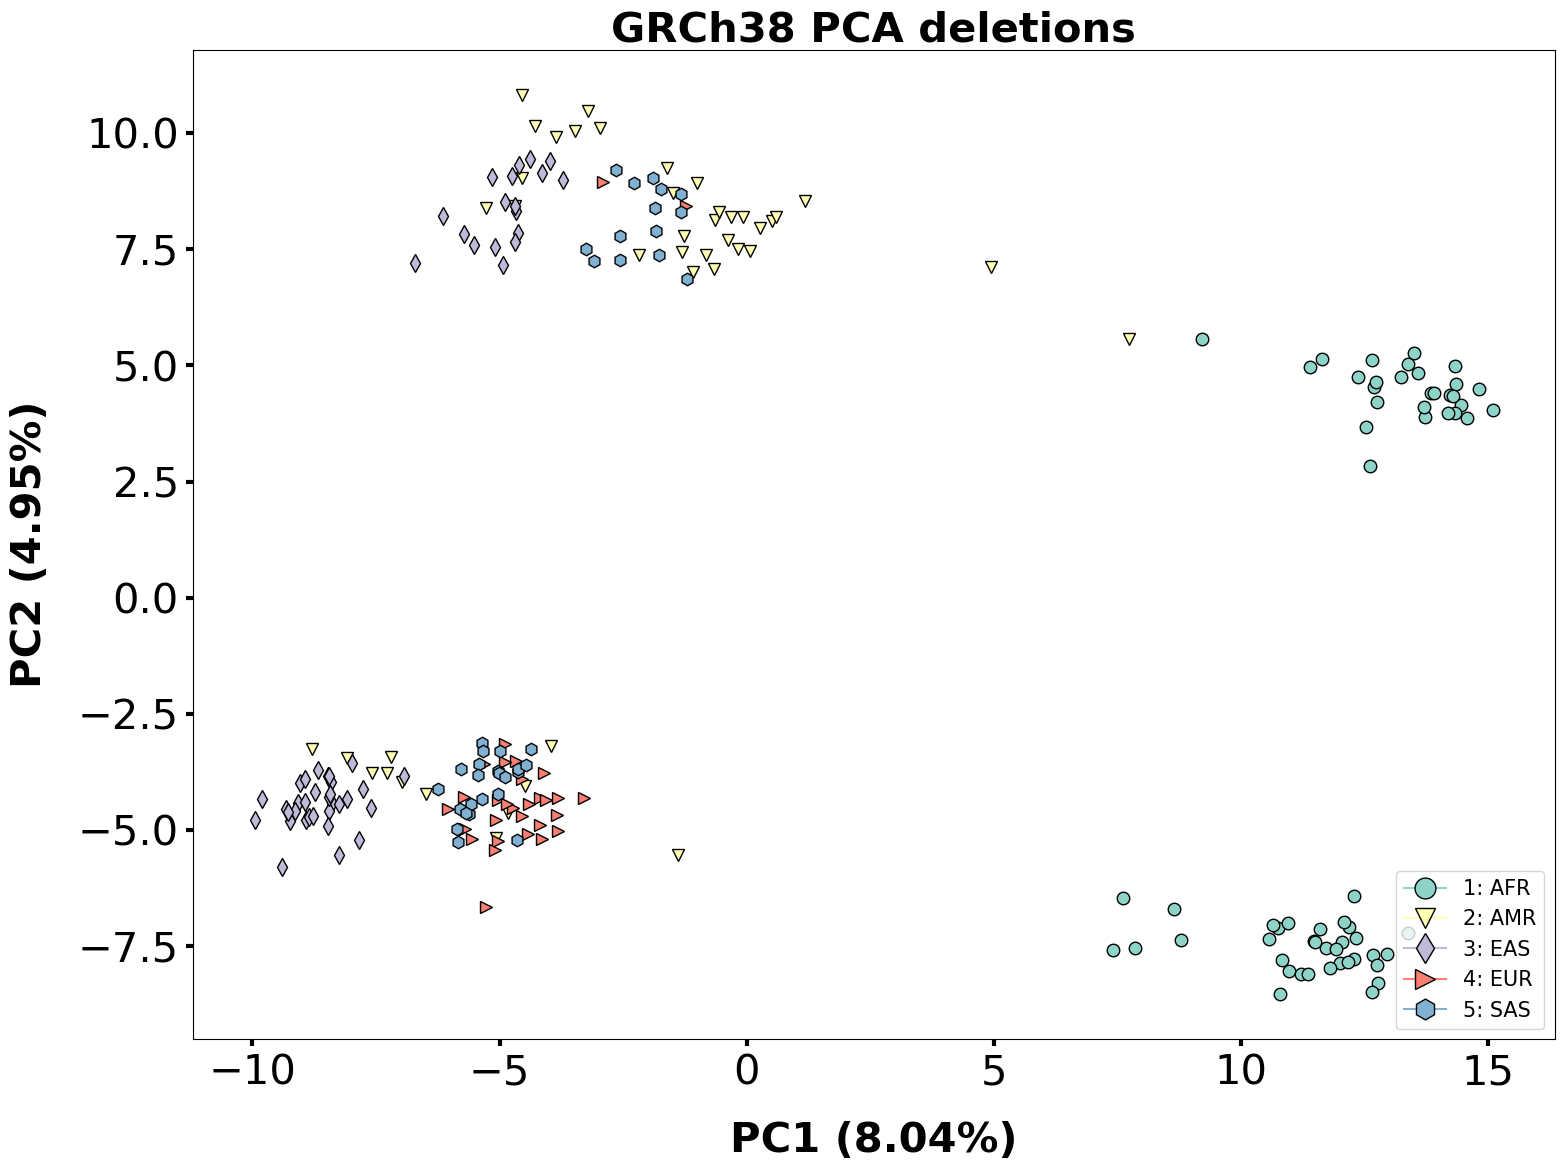

In [6]:
# PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(counts)

df_pca= pd.DataFrame(pca_results,
                          columns=['component_1','component_2'

                                  ],
                          index=counts.index)

df_pca = features.merge(df_pca, left_index=True, right_index=True)


components = [1,2]

combinations_components = list(combinations(components,2))
#for i in combinations_components:
#    plot_scatter_cluster(data=df_pca, abscissa='component_'+str(i[0]), ordinate='component_'+str(i[1]), label_horizontal='PC '+ str(i[0]), label_vertical='PC '+str(i[1]), factor='10-Region', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
    #print(str(i[0]))

plot_scatter_cluster_shape(data=df_pca, abscissa='component_1', ordinate='component_2', label_horizontal='PC1 (8.04%)', label_vertical='PC2 (4.95%)', 
                           factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
plt.title("GRCh38 PCA deletions", size=30, fontweight="bold")

plt.savefig('../plots/grch38_pca_deletions_pc12.png', transparent=True)

In [7]:
pca.explained_variance_ratio_

array([0.08040121, 0.04959808])

In [8]:
group_a = df_pca[df_pca['component_2'] > 0]
group_b = df_pca[df_pca['component_2'] < 0]

group_a.drop(columns=['Superpopulation code'], inplace=True)
group_b.drop(columns=['Superpopulation code'], inplace=True)

group_a = pd.get_dummies(group_a)
group_b = pd.get_dummies(group_b)


#ANOVA
results_anova = []
for i in group_a.columns:
    d = stats.f_oneway(group_a[i], group_b[i])
    if d.pvalue <0.05:
        results_anova.append(i)

#T-test
results_ttest = []
for i in group_a.columns:
    d = stats.ttest_ind(group_a[i], group_b[i])
    if d.pvalue <0.05:   
        results_ttest.append(i)
        
results_anova = results_anova[:-2]


dontwant = data_grch37.iloc[results_anova]

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/2933717630.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_a.drop(columns=['Superpopulation code'], inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/2933717630.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group_b.drop(columns=['Superpopulation code'], inplace=True)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/lib/py

                        1    4         5   10   12        13   14   15  \
Superpopulation code                                                     
EUR                   2.0  2.0  0.777778  0.0  2.0  1.142857  2.0  2.0   
EUR                   2.0  2.0  0.000000  0.0  2.0  0.666667  2.0  2.0   
EUR                   2.0  2.0  1.000000  0.0  2.0  0.000000  2.0  2.0   
EUR                   2.0  2.0  0.333333  0.0  2.0  0.000000  2.0  2.0   
EUR                   2.0  2.0  0.900000  0.0  2.0  0.000000  2.0  2.0   
...                   ...  ...       ...  ...  ...       ...  ...  ...   
SAS                   2.0  2.0  0.500000  0.0  2.0  0.000000  2.0  2.0   
SAS                   2.0  2.0  0.625000  0.0  2.0  1.000000  2.0  2.0   
SAS                   2.0  2.0  0.500000  0.0  2.0  0.666667  2.0  2.0   
SAS                   2.0  2.0  1.000000  0.0  2.0  0.000000  2.0  2.0   
SAS                   2.0  2.0  1.200000  0.0  2.0  0.333333  2.0  2.0   

                            18       

/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:247: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:
/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:264: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:


Text(0.5, 1.0, 'GRCh38 PCA deletions')

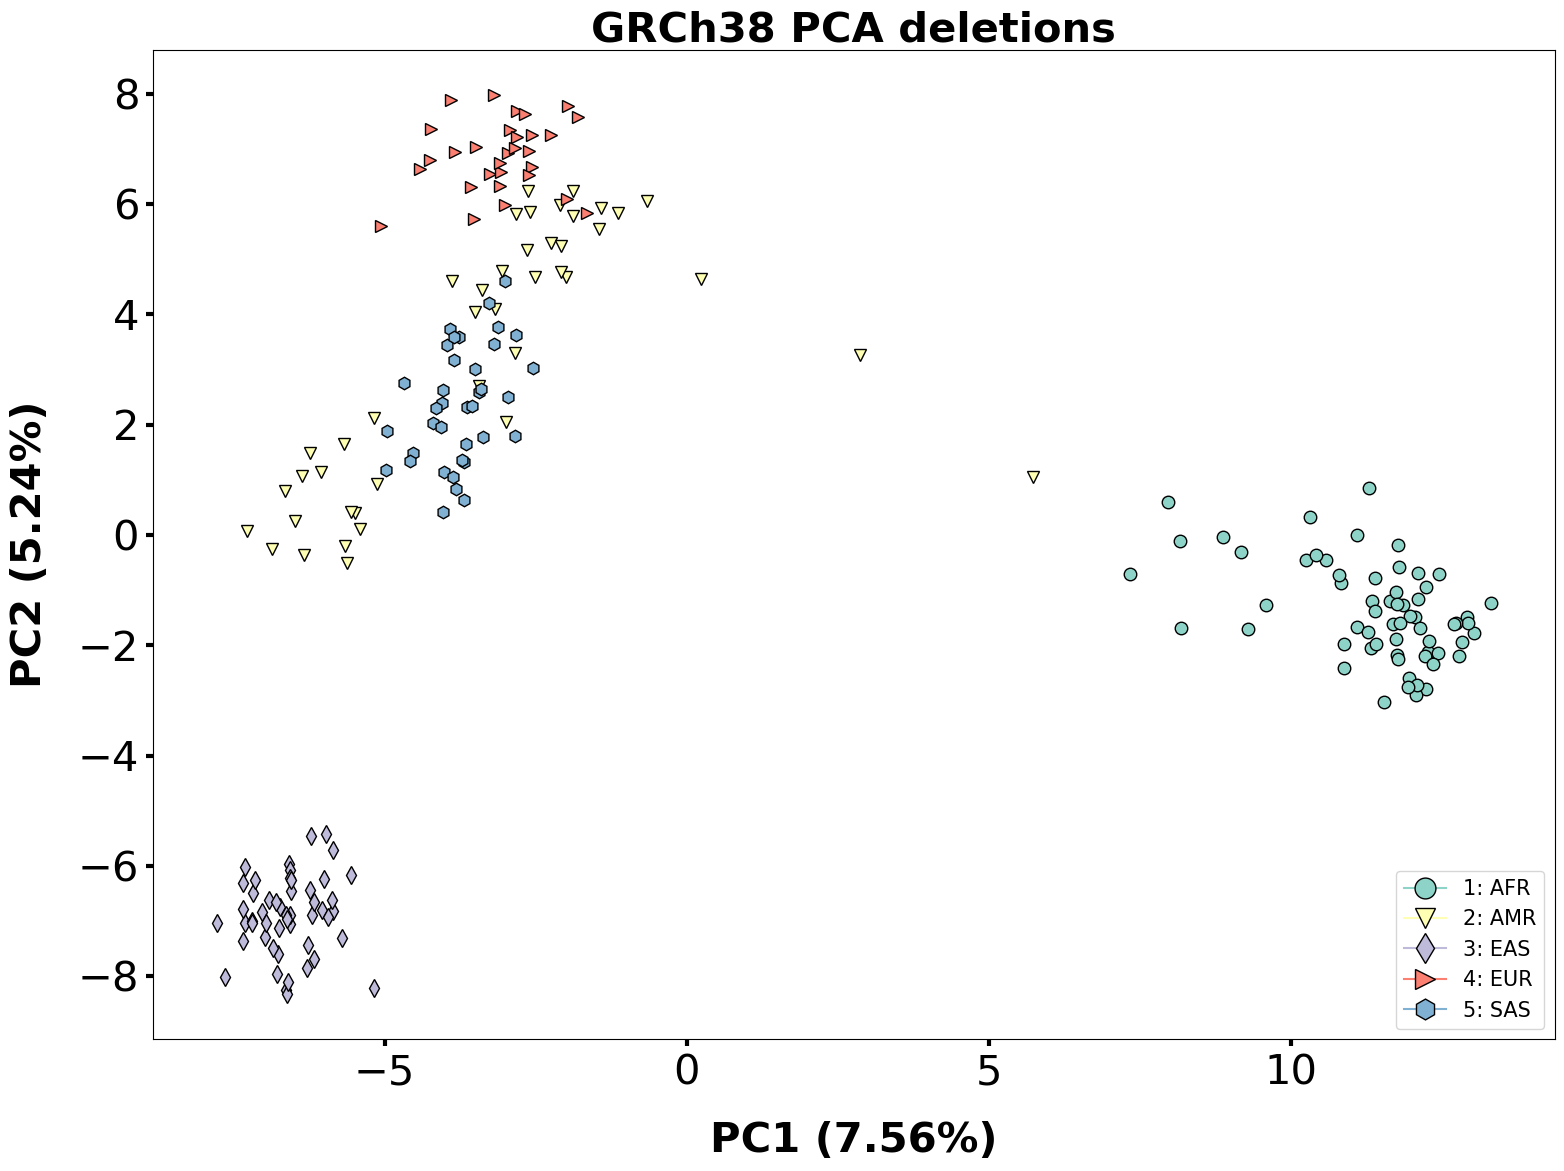

In [9]:


## Rearrange deletions (remove CNVs)
data_grch37_filter = data_grch37.drop(index=results_anova)

data_grch37_deletions = data_grch37_filter[(data_grch37_filter[data_grch37_filter.columns[:]]<=2).all(axis=1)]
data_grch37_deletions = data_grch37_deletions[(data_grch37_deletions[data_grch37.columns[:]]>=0).all(axis=1)]
#data_grch37_deletions = data_grch37_deletions[(data_grch37_deletions[data_grch37.columns[:]]!=1).all(axis=1)]
counts = data_grch37_deletions.T
counts = counts.sort_index()


features = anotation.merge(counts, left_index=True, right_index=True)
#features = features.loc[:,["Superpopulation code"]]
features = features.sort_index()

data_grch37_deletions.to_csv('../data/grch38_deletions.csv')


## PCA 
pca = PCA(n_components=2)
pca_results = pca.fit_transform(counts)

df_pca= pd.DataFrame(pca_results,
                          columns=['component_1','component_2'

                                  ],
                          index=counts.index)

df_pca = features.merge(df_pca, left_index=True, right_index=True)

components = [1,2]

combinations_components = list(combinations(components,2))
#for i in combinations_components:
#    plot_scatter_cluster(data=df_pca, abscissa='component_'+str(i[0]), ordinate='component_'+str(i[1]), label_horizontal='PC '+ str(i[0]), label_vertical='PC '+str(i[1]), factor='10-Region', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
    #print(str(i[0]))

plot_scatter_cluster_shape(data=df_pca, abscissa='component_1', ordinate='component_2', label_horizontal='PC1 (7.56%)', label_vertical='PC2 (5.24%)', 
                           factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
plt.title("GRCh38 PCA deletions", size=30, fontweight="bold")

#plt.savefig('../plots/grch38_pca_deletions_pc12.png', transparent=True)


<Figure size 2000x700 with 0 Axes>

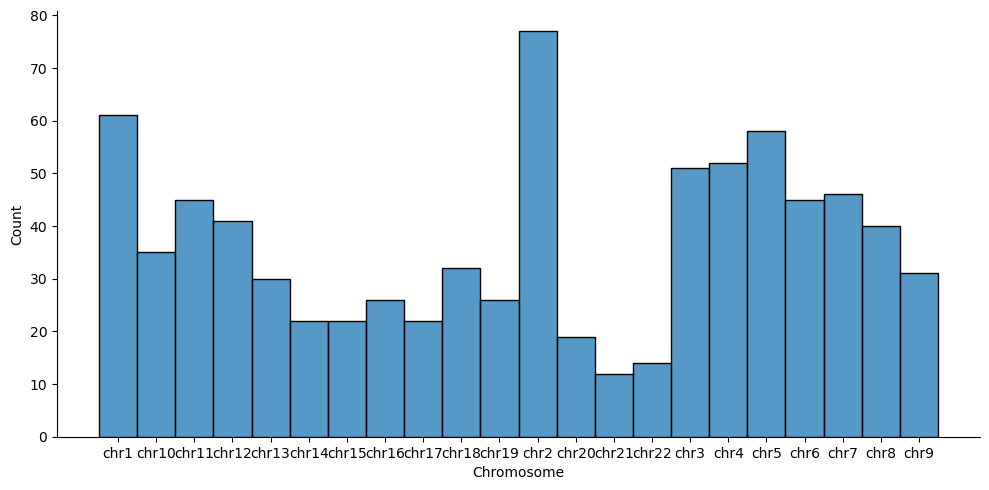

In [10]:
dontwant = cnv.iloc[results_anova]

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=[20,7])
sns.displot(dontwant['Chromosome'], height=5, aspect=2)

In [11]:
dontwant[['Chromosome','Start','End']].to_csv('../data/cnvs_conflict_grch38.csv', sep='\t')

In [12]:
dontwant

,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
3,chr1,713327,714478,0.0,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1151.0
6,chr1,976708,978019,2.0,1.00,2.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.000000,2.0,1.4,2.0,1311.0
7,chr1,1075890,1079399,2.0,1.25,1.0,1.5,1.5,2.0,1.5,...,2.0,2.0,2.0,2.0,2.0,1.500000,2.0,2.0,2.0,3509.0
17,chr1,2093115,2095945,2.0,2.00,2.0,2.0,2.0,2.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.000000,1.0,2.0,2.0,2830.0
22,chr1,3299144,3300425,1.0,0.00,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.000000,1.0,1.5,1.6,1281.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10933,chr9,133069711,133085504,2.0,2.00,2.0,1.0,1.0,1.0,1.0,...,2.0,1.0,1.5,2.0,2.0,1.000000,2.0,2.0,2.0,15793.0
10942,chr9,134115318,134118543,1.0,0.00,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.333333,1.0,0.0,1.0,3225.0
10947,chr9,134470012,134471135,2.0,2.00,2.0,2.0,1.0,2.0,1.0,...,1.0,2.0,2.0,2.0,2.0,1.000000,2.0,2.0,2.0,1123.0
10975,chr9,137888930,137890828,2.0,2.00,2.0,2.0,2.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.0,1898.0


In [13]:
#Duplications
data_grch37_duplications = data_grch37[(data_grch37[data_grch37.columns[1:]]>=2).all(axis=1)]
#data_grch37_duplications =  data_grch37_duplications[(data_grch37_duplications[data_grch37_duplications.columns[1:]]>1).all(axis=1)]
counts = data_grch37_duplications.T
counts = counts.sort_index()
counts = counts.fillna(2)
counts = counts.sort_index()
counts

,23,44,48,58,62,99,101,122,142,146,...,10844,10846,10851,10874,10878,10884,10901,10926,10927,10979
HG00097,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
HG00099,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
HG00126,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0
HG00128,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
HG00133,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NA21093,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NA21102,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NA21106,4.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NA21110,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


                        1    4         5   10   12        13   14   15  \
Superpopulation code                                                     
EUR                   2.0  2.0  0.777778  0.0  2.0  1.142857  2.0  2.0   
EUR                   2.0  2.0  0.000000  0.0  2.0  0.666667  2.0  2.0   
EUR                   2.0  2.0  1.000000  0.0  2.0  0.000000  2.0  2.0   
EUR                   2.0  2.0  0.333333  0.0  2.0  0.000000  2.0  2.0   
EUR                   2.0  2.0  0.900000  0.0  2.0  0.000000  2.0  2.0   
...                   ...  ...       ...  ...  ...       ...  ...  ...   
SAS                   2.0  2.0  0.500000  0.0  2.0  0.000000  2.0  2.0   
SAS                   2.0  2.0  0.625000  0.0  2.0  1.000000  2.0  2.0   
SAS                   2.0  2.0  0.500000  0.0  2.0  0.666667  2.0  2.0   
SAS                   2.0  2.0  1.000000  0.0  2.0  0.000000  2.0  2.0   
SAS                   2.0  2.0  1.200000  0.0  2.0  0.333333  2.0  2.0   

                            18       

/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:247: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:
/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:264: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:


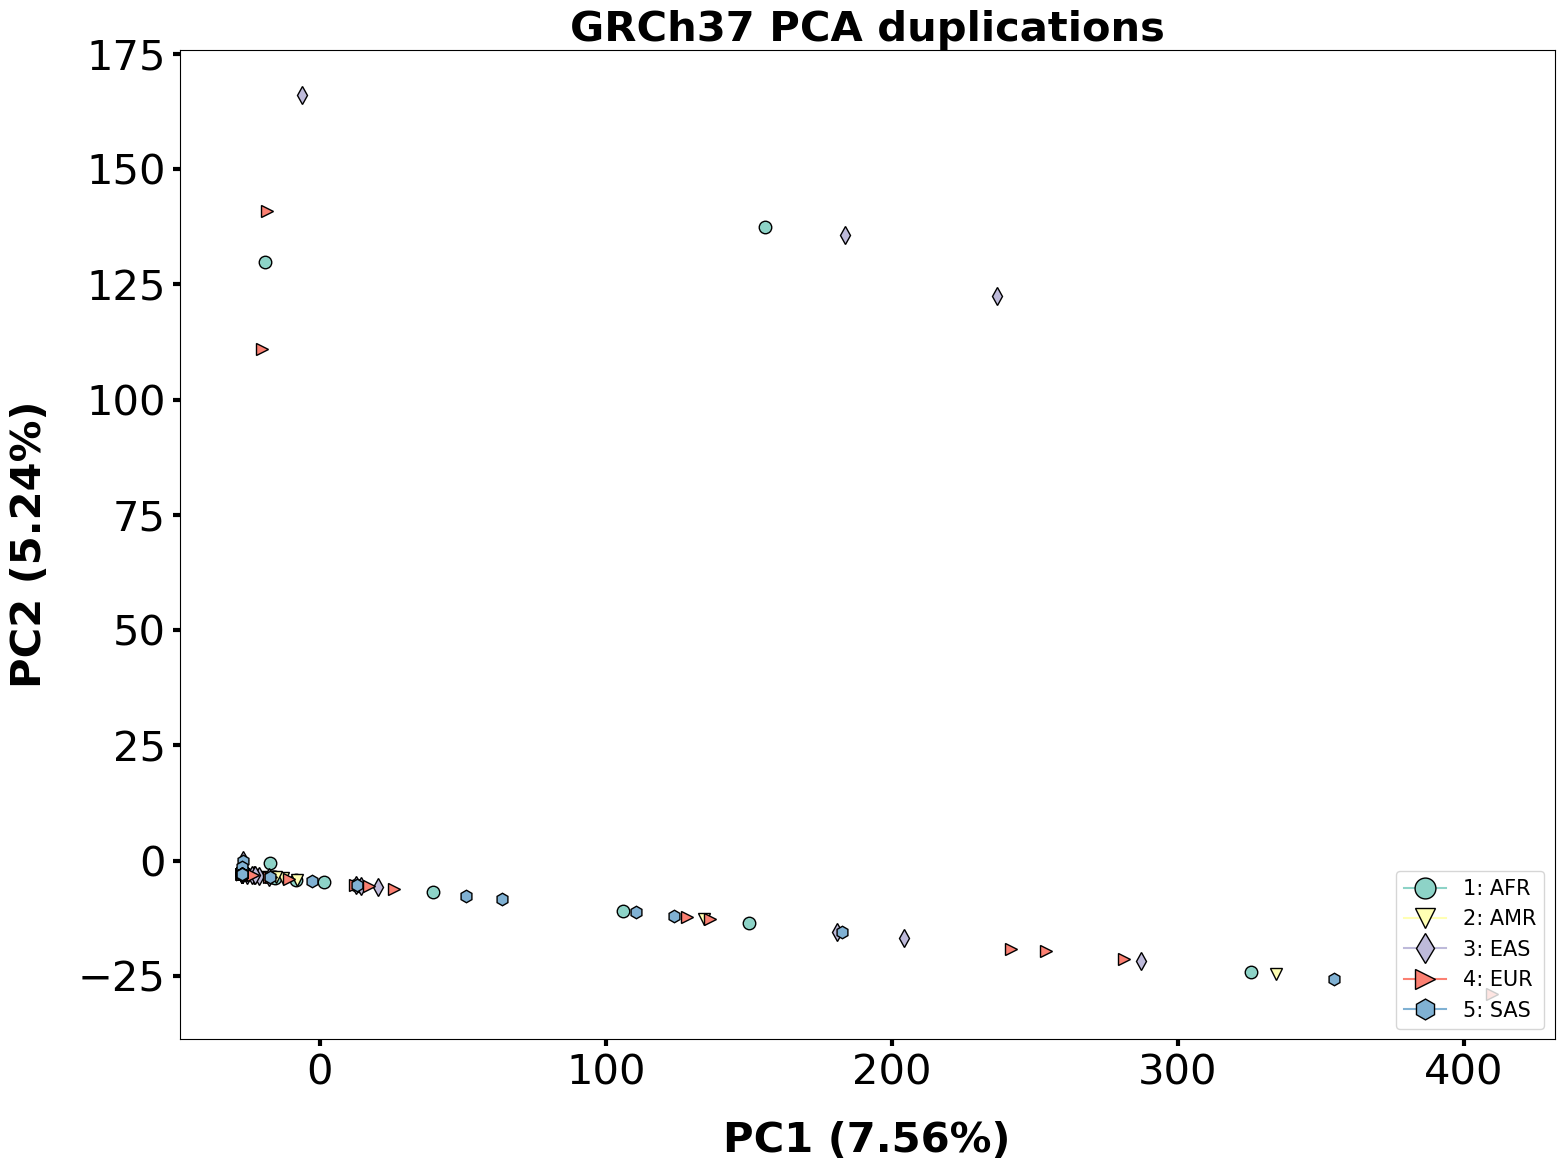

In [14]:
pca = PCA(n_components=10)
pca_results = pca.fit_transform(counts)

df_pca= pd.DataFrame(pca_results,
                          columns=['component_1','component_2', 'component_3', 'component_4',
                                  'component_5',
                                  'component_6',
                                  'component_7',
                                  'component_8',
                                  'component_9',
                                   'component_10'
                                  ],
                          index=features.index)




df_pca = features.merge(df_pca, left_index=True, right_index=True)

components = [1,2,3,4,5,6,7,8,9,10]

combinations_components = list(combinations(components,2))
#for i in combinations_components:
#    plot_scatter_cluster(data=df_pca, abscissa='component_'+str(i[0]), ordinate='component_'+str(i[1]), label_horizontal='PC '+ str(i[0]), label_vertical='PC '+str(i[1]), factor='10-Region', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
    #print(str(i[0]))

plot_scatter_cluster_shape(data=df_pca, abscissa='component_1', ordinate='component_2', label_horizontal='PC1 (7.56%)', label_vertical='PC2 (5.24%)', factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
plt.title("GRCh37 PCA duplications", size=30, fontweight="bold")

plt.savefig('../plots/grch38_pca_duplications_pc12.png', transparent=True)

<h2> Vst 

In [15]:
####
#features = anotation.loc[:,["Superpopulation code"]]
data_grch37_ = features[['Superpopulation code']].merge(data_grch37.T, left_index=True, right_index=True)
data_grch37_ = data_grch37_.sort_values(by='Superpopulation code')
data_grch37_.to_csv('../data/input_dapc_grch38_hprc.csv')

####### Groupby regions #######
dt_group = data_grch37_.groupby('Superpopulation code')

dt_groupped = []
regions = features['Superpopulation code'].unique()
regions.sort()
for i in regions:
    dt_groupped.append(dt_group.get_group(str(i)))
    

#### Names to pair-population
regions = data_grch37_['Superpopulation code'].unique()
regions.sort()

combination_names = []
for i in list(combinations(regions,2)):
    combination_names.append(i[0]+str('-')+i[1])
    
for j in dt_groupped:
    j.drop(columns=['Superpopulation code'], inplace=True)

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/3953351230.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  j.drop(columns=['Superpopulation code'], inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/3953351230.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  j.drop(columns=['Superpopulation code'], inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/3953351230.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [16]:
## VST for pair-population
vst_dt = []

combination_regions = list(combinations([0,1,2,3,4],2))
for region in combination_regions:
        statistic = vst_function((dt_groupped[region[0]]), (dt_groupped[region[1]]))
        vst_dt.append(statistic)

vst_dt = pd.DataFrame(vst_dt).set_axis(combination_names)
vst_dt

,0,1,2,3,4,5,6,7,8,9,...,10972,10973,10974,10975,10976,10977,10978,10979,10980,10981
AFR-AMR,0.026646,NaN,0.002360,0.153964,0.074947,0.338360,0.015866,0.007076,0.153838,0.068370,...,0.415592,0.000020,0.024448,0.000657,0.306750,0.062434,0.001038,NaN,0.001463,0.034482
AFR-EAS,0.003304,NaN,0.000101,0.211932,0.126734,0.143849,0.038585,0.079557,0.001172,0.117755,...,0.322168,0.007729,0.004829,0.007265,0.000579,0.036756,0.215915,NaN,0.071273,0.086160
AFR-EUR,0.061545,0.022711,0.000446,0.294066,0.095846,0.385961,0.032989,0.095110,0.019061,0.130951,...,0.298705,0.016064,0.003532,0.156293,0.246284,0.067526,0.036174,NaN,0.337440,0.153960
AFR-SAS,0.000893,NaN,0.004228,0.181028,0.108334,0.375569,0.020045,0.179636,0.053736,0.149993,...,0.299250,0.003801,0.011651,0.011457,0.142156,0.022005,0.086796,NaN,0.116290,0.059076
AMR-EAS,0.013410,NaN,0.001825,0.005257,0.025556,0.058613,0.100485,0.041473,0.134747,0.006240,...,0.060916,0.006333,0.018682,0.012639,0.318078,0.179719,0.176717,NaN,0.042030,0.029665
AMR-EUR,0.012545,0.019907,0.001327,0.086442,0.019653,0.001061,0.090547,0.060256,0.070594,0.021643,...,0.031723,0.016187,0.014344,0.132693,0.001075,0.009690,0.024225,NaN,0.268090,0.061502
AMR-SAS,0.021874,NaN,0.000539,0.004683,0.022063,0.000111,0.070511,0.135787,0.046095,0.027931,...,0.020362,0.003083,0.009027,0.006533,0.056867,0.011465,0.065853,NaN,0.078565,0.005170
EAS-EUR,0.049087,0.021097,0.000164,0.067285,NaN,0.051926,0.000004,0.000857,0.011958,0.007103,...,0.003226,0.046126,NaN,0.185185,0.259769,0.176471,0.087097,NaN,0.149128,0.001643
EAS-SAS,0.000825,NaN,0.003866,0.000011,NaN,0.059997,0.003281,0.025425,0.041332,0.011366,...,0.006090,0.000627,0.015713,0.031797,0.142507,0.103386,0.038516,NaN,0.010125,0.013053
EUR-SAS,0.073818,0.018687,0.003875,0.051480,NaN,0.000601,0.003580,0.024480,0.007612,0.000593,...,0.000588,0.036428,0.012285,0.088029,0.037324,0.022384,0.013252,NaN,0.080488,0.031881


In [17]:
filtering_vst = pd.DataFrame(vst_dt)>=0.2
filtering_vst = filtering_vst.loc[:, filtering_vst.any()]
#filtering_vst = filtering_vst.set_axis(combination_names)
filtering_vst 

,3,5,11,21,22,40,52,68,83,88,...,10938,10942,10946,10950,10954,10967,10972,10976,10978,10980
AFR-AMR,False,True,True,False,True,False,False,False,False,False,...,True,False,True,False,False,False,True,True,False,False
AFR-EAS,True,False,False,False,True,True,False,False,False,False,...,True,False,False,True,True,False,True,False,True,False
AFR-EUR,True,True,True,False,False,False,True,True,True,False,...,False,False,False,False,True,False,True,True,False,True
AFR-SAS,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,True,True,True,False,False,False
AMR-EAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
AMR-EUR,False,False,False,False,False,False,True,True,False,True,...,False,True,False,False,False,False,False,False,False,True
AMR-SAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
EAS-EUR,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
EAS-SAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
EUR-SAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
## Coordinates anotation 
vst_dt = vst_dt.T
vst_dt.insert (0, 'Chromosome', cnv['Chromosome'])
vst_dt.insert (1, 'Start', cnv['Start'])
vst_dt.insert (2, 'End', cnv['End'])
#vst_dt.insert (3, 'Type', cnv['Type'])
vst_dt = vst_dt.round(5)
vst_dt_grch37 = vst_dt.replace(np.NaN, 0)
#vst_dt.to_csv('../data/vst_results_grch37.csv', index=False)
#vst_dt_grch37['Chromosome'] = 'chr' + vst_dt_grch37['Chromosome'].astype(str)
vst_dt_grch37['Start'] = vst_dt_grch37['Start'].astype(int)
vst_dt_grch37['End'] = vst_dt_grch37['End'].astype(int)
vst_dt_grch37

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
0,chr1,65562,66618,0.02665,0.00330,0.06155,0.00089,0.01341,0.01255,0.02187,0.04909,0.00083,0.07382
1,chr1,96603,98682,0.00000,0.00000,0.02271,0.00000,0.00000,0.01991,0.00000,0.02110,0.00000,0.01869
2,chr1,126241,707779,0.00236,0.00010,0.00045,0.00423,0.00183,0.00133,0.00054,0.00016,0.00387,0.00387
3,chr1,713327,714478,0.15396,0.21193,0.29407,0.18103,0.00526,0.08644,0.00468,0.06728,0.00001,0.05148
4,chr1,725043,728380,0.07495,0.12673,0.09585,0.10833,0.02556,0.01965,0.02206,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10977,chr9,138081484,138087539,0.06243,0.03676,0.06753,0.02200,0.17972,0.00969,0.01147,0.17647,0.10339,0.02238
10978,chr9,138125044,138139226,0.00104,0.21592,0.03617,0.08680,0.17672,0.02422,0.06585,0.08710,0.03852,0.01325
10979,chr9,138183904,138186463,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
10980,chr9,138190962,138196916,0.00146,0.07127,0.33744,0.11629,0.04203,0.26809,0.07857,0.14913,0.01013,0.08049


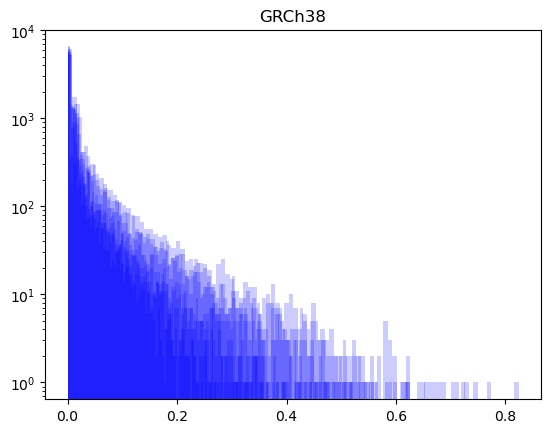

In [19]:
#sns.set_palette("bright")
for i in vst_dt_grch37.iloc[:,4:27].columns:
    plt.hist(vst_dt_grch37[i], bins=100, alpha=0.2, log=True, color="blue")
    plt.title('GRCh38')
    plt.savefig('../plots/grch38_vst_values_distribution.png', transparent=True)

In [20]:
vst_dt_filtering_location = vst_dt_grch37.iloc[filtering_vst.columns]
vst_dt_filtering_location#[vst_dt_filtering_location['chr'] == '8'].sort_values(by='WestEurasia-Oceania', ascending=False).head(50)

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
3,chr1,713327,714478,0.15396,0.21193,0.29407,0.18103,0.00526,0.08644,0.00468,0.06728,0.00001,0.05148
5,chr1,729842,914823,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
11,chr1,1444487,1534886,0.22184,0.16136,0.33825,0.17075,0.01518,0.02553,0.00614,0.08516,0.00180,0.06136
21,chr1,2976522,2977705,0.17556,0.10969,0.09944,0.20829,0.02427,0.01501,0.00571,0.00059,0.05195,0.03731
22,chr1,3299144,3300425,0.29022,0.25884,0.08182,0.06764,0.00877,0.12221,0.15379,0.08257,0.11185,0.00248
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10967,chr9,137359057,137361507,0.08183,0.19943,0.00460,0.20035,0.03155,0.04676,0.03286,0.14329,0.00002,0.16162
10972,chr9,137818517,137819670,0.41559,0.32217,0.29870,0.29925,0.06092,0.03172,0.02036,0.00323,0.00609,0.00059
10976,chr9,138017889,138019594,0.30675,0.00058,0.24628,0.14216,0.31808,0.00107,0.05687,0.25977,0.14251,0.03732
10978,chr9,138125044,138139226,0.00104,0.21592,0.03617,0.08680,0.17672,0.02422,0.06585,0.08710,0.03852,0.01325


In [21]:
vst_dt_filtered = vst_dt_grch37.iloc[filtering_vst.T.index]
#vst_dt_filtered.to_csv('../data/vst_candidates_grch37.csv', index=False) 
vst_grch37 = vst_dt_filtered
vst_grch37

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
3,chr1,713327,714478,0.15396,0.21193,0.29407,0.18103,0.00526,0.08644,0.00468,0.06728,0.00001,0.05148
5,chr1,729842,914823,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
11,chr1,1444487,1534886,0.22184,0.16136,0.33825,0.17075,0.01518,0.02553,0.00614,0.08516,0.00180,0.06136
21,chr1,2976522,2977705,0.17556,0.10969,0.09944,0.20829,0.02427,0.01501,0.00571,0.00059,0.05195,0.03731
22,chr1,3299144,3300425,0.29022,0.25884,0.08182,0.06764,0.00877,0.12221,0.15379,0.08257,0.11185,0.00248
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10967,chr9,137359057,137361507,0.08183,0.19943,0.00460,0.20035,0.03155,0.04676,0.03286,0.14329,0.00002,0.16162
10972,chr9,137818517,137819670,0.41559,0.32217,0.29870,0.29925,0.06092,0.03172,0.02036,0.00323,0.00609,0.00059
10976,chr9,138017889,138019594,0.30675,0.00058,0.24628,0.14216,0.31808,0.00107,0.05687,0.25977,0.14251,0.03732
10978,chr9,138125044,138139226,0.00104,0.21592,0.03617,0.08680,0.17672,0.02422,0.06585,0.08710,0.03852,0.01325


In [22]:
#vst_dt_sb = vst_dt_filtered.drop(columns=['Chromosome', 'Start','End'])
#data_grch37_.drop(columns=['Superpopulation'], inplace=True)
#data_grch37_ = data_grch37_.T.iloc[vst_dt_filtered.index]
vst_grch37.iloc[:,0:3].to_csv('../data/vst_candidates_coordinates_grch38.bed', sep='\t', header=False, index=False)

<h2> Gene anotation for GRCh38

In [23]:
## Anotations
vst_grch37_filtered_ranges = PyRanges(vst_grch37)
grch38_genes = pd.read_csv('/Users/luciabazan/Downloads/grch38_genes_gencode_v47')
grch38_genes.columns = ['#bin', 'name', 'Chromosome', 'strand', 'Start', 'End', 'cdsStart',
       'cdsEnd', 'exonCount', 'exonStarts', 'exonEnds', 'score', 'name2',
       'cdsStartStat', 'cdsEndStat', 'exonFrames']
grch38_genes = grch38_genes[['Chromosome', 'Start', 'End', 'name2']]
grch38_genes = PyRanges(grch38_genes)

grch38_ranges = PyRanges(cnv)


In [24]:
#Genes
grch38_coordinates_genes = vst_grch37_filtered_ranges.nearest(grch38_genes)
grch38_coordinates_genes = grch38_coordinates_genes.as_df()
grch38_coordinates_genes = grch38_coordinates_genes[grch38_coordinates_genes['Distance'] <1 ]
grch37_coordinates_genes = grch38_coordinates_genes

In [25]:
#Table 
d = {'Data': ['Significan differentiated CNVs', 'Differentiate CNVs in genes'],
     'Africa-America': [len(vst_dt_filtered[vst_dt_filtered['AFR-AMR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-AMR'] > 0.2])
                       ],
     'Africa-EastAsia': [len(vst_dt_filtered[vst_dt_filtered['AFR-EAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-EAS'] > 0.2])
                       ],
     'Africa-SouthAsia': [len(vst_dt_filtered[vst_dt_filtered['AFR-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-SAS'] > 0.2])
                       ],
     'Africa-Europe': [len(vst_dt_filtered[vst_dt_filtered['AFR-EUR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-EUR'] > 0.2])
                       ],
     'America-EastAsia': [len(vst_dt_filtered[vst_dt_filtered['AMR-EAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AMR-EAS'] > 0.2])
                       ],
     'America-SouthAsia': [len(vst_dt_filtered[vst_dt_filtered['AMR-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AMR-SAS'] > 0.2])
                       ],
     'America-Europe': [len(vst_dt_filtered[vst_dt_filtered['AMR-EUR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AMR-EUR'] > 0.2])
                       ],
     'EastAsia-SouthAsia': [len(vst_dt_filtered[vst_dt_filtered['EAS-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['EAS-SAS'] > 0.2])
                       ],
     'EastAsia-Europe': [len(vst_dt_filtered[vst_dt_filtered['EAS-EUR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['EAS-EUR'] > 0.2])
                       ],
     'SouthAsia-Europe': [len(vst_dt_filtered[vst_dt_filtered['EUR-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['EUR-SAS'] > 0.2])
                       ],
     
         }

df_map_grch38 = pd.DataFrame(data=d)
df_map_grch38.T

,0,1
Data,Significan differentiated CNVs,Differentiate CNVs in genes
Africa-America,269,177
Africa-EastAsia,482,321
Africa-SouthAsia,318,212
Africa-Europe,384,249
America-EastAsia,151,95
America-SouthAsia,39,26
America-Europe,139,94
EastAsia-SouthAsia,114,82
EastAsia-Europe,287,191


<h1> T2T-CHM13

In [26]:
chm13 = pd.read_csv('../data/input_t2t_hprc.csv', index_col=0)
chm13['Chromosome'] = 'chr' + chm13['Chromosome'].astype(str)
chm13['Start'] = chm13['Start'].astype(int)
chm13['End'] = chm13['End'].astype(int)
chm13.iloc[:,0:3].to_csv('../data/cnvs_coordinate_t2t.bed', sep='\t', header=False, index=False)
data_chm13 = chm13.iloc[:,3:227]
#data_grch37 = data_grch37.T
data_chm13 = data_chm13.fillna(2)
data_chm13 = data_chm13.drop(columns = ['HG03369','HG03942'])
data_chm13

,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,HG00232,HG00235,HG00253,...,NA20809,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144
0,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0
1,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,2.0,1.0,1.0,...,2.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,2.0
2,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,1.0,1.5,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0
3,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
4,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
12730,1.0,2.0,2.000000,2.0,1.000000,2.0,0.0,2.0,2.0,2.0,...,2.0,1.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,0.0
12731,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
12732,2.0,2.0,2.000000,0.0,1.000000,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0


In [27]:
data_chm13_deletions = data_chm13[(data_chm13[data_chm13.columns[:]]<=2).all(axis=1)]
data_chm13_deletions.to_csv('../data/t2t_deletions.csv')

<h2>PCA 

                      component_1  component_2
Superpopulation code                          
EUR                     11.351725    13.017341
EUR                     10.092671    17.523577
EUR                     12.106150    18.646222
EUR                     10.509139    14.938305
EUR                      8.816066    14.548665
...                           ...          ...
SAS                     11.848000     7.204737
SAS                     10.953630     7.842734
SAS                     10.016561     7.139738
SAS                     11.329797     5.650184
SAS                     11.985471     4.593571

[222 rows x 2 columns]
Count of groups by factor: 5


/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:247: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:
/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:264: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:


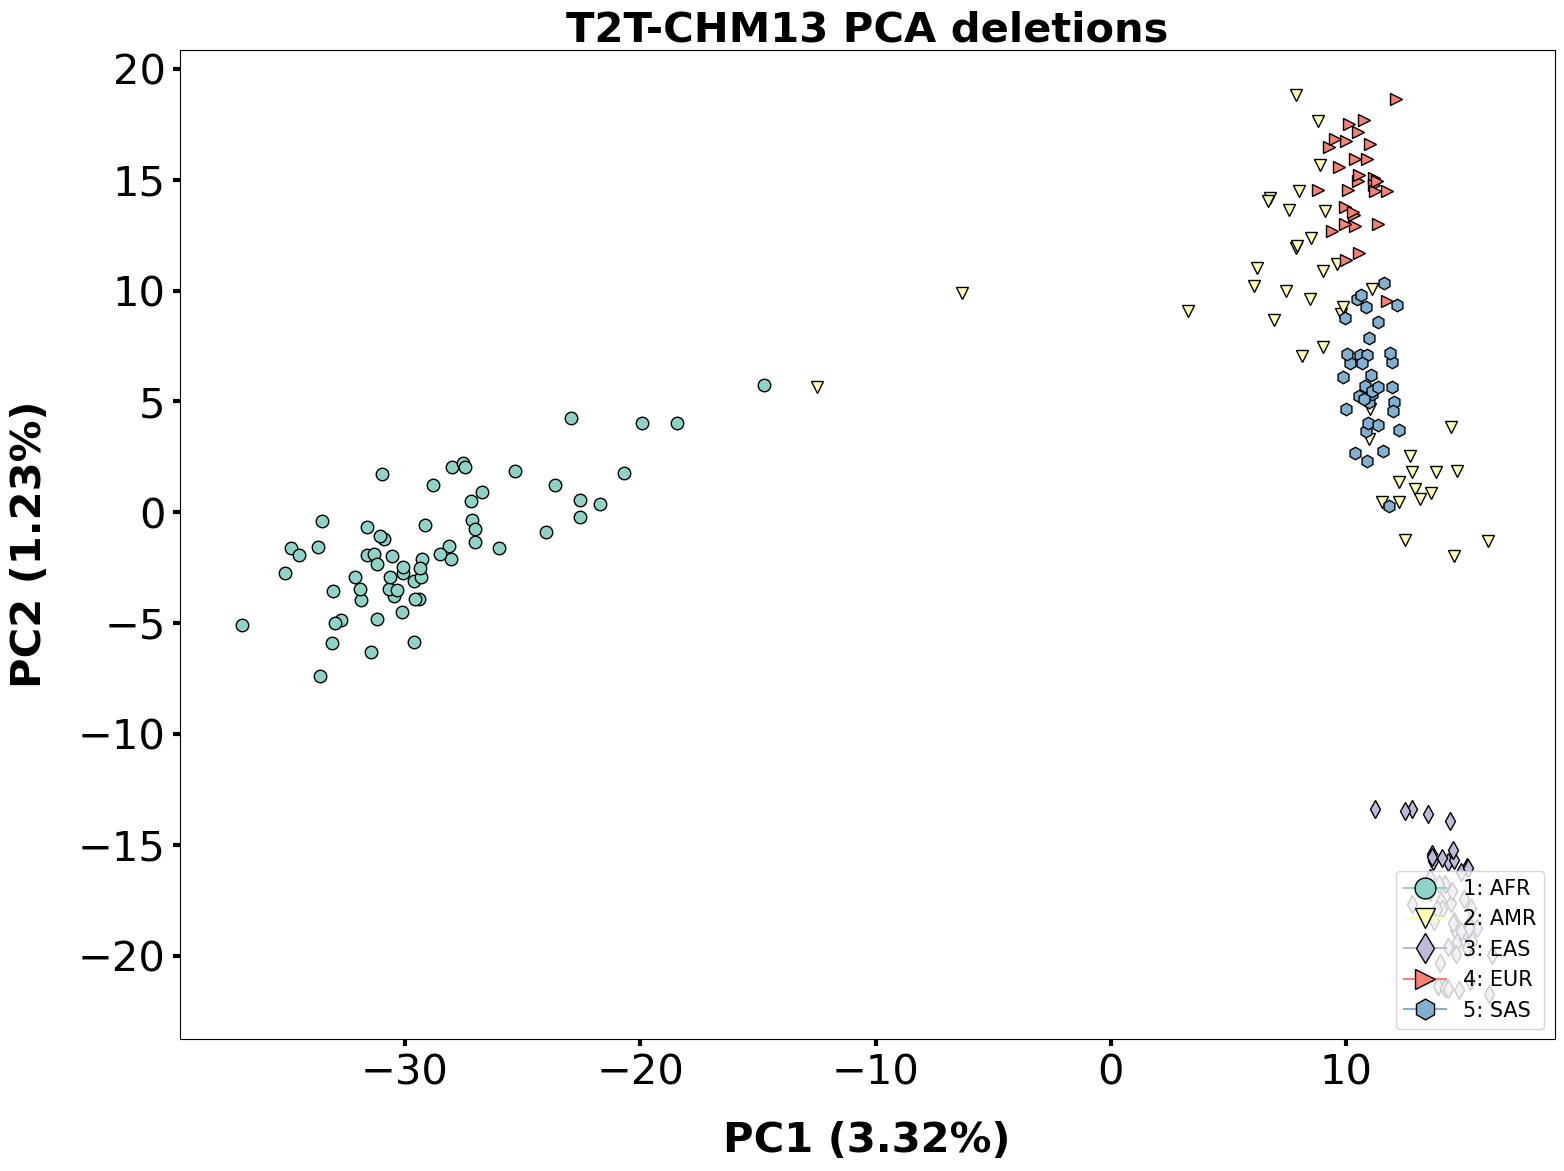

In [28]:
### Deletions
data_chm13_deletions = data_chm13[(data_chm13[data_chm13.columns[:]]<=2).all(axis=1)]
counts = data_chm13_deletions.T
counts = counts.sort_index()

features = anotation.merge(counts, left_index=True, right_index=True)
features = features.loc[:,["Superpopulation code"]]
features = features.sort_index()
features

x = StandardScaler().fit_transform(counts)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(x)

df_pca= pd.DataFrame(pca_results,
                          columns=['component_1','component_2'],
                          index=features.index)


df_pca = features.merge(df_pca, left_index=True, right_index=True)

components = [1,2]

#combinations_components = list(combinations(components,2))
#for i in combinations_components:
#    plot_scatter_cluster_shape(data=df_pca, abscissa='component_'+str(i[0]), ordinate='component_'+str(i[1]), label_horizontal='PC '+ str(i[0]), label_vertical='PC '+str(i[1]), factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)


plot_scatter_cluster_shape(data=df_pca, abscissa='component_1', ordinate='component_2', label_horizontal='PC1 (3.32%)', label_vertical='PC2 (1.23%)', factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
plt.title("T2T-CHM13 PCA deletions", size=30, fontweight="bold")

plt.savefig('../plots/t2t_pca_deletions_pc12.png', transparent=True)

In [29]:
pca.explained_variance_ratio_

array([0.03329363, 0.01237671])

                      component_1  component_2  component_3  component_4  \
Superpopulation code                                                       
EUR                     -0.411432    -0.607742    -0.333314    -0.232381   
EUR                     -0.226721    -0.255439    -0.307442    -0.118001   
EUR                     -0.408028    -0.284176    -0.826190    -0.573142   
EUR                      0.798585    -0.179801    -0.230579    -0.178458   
EUR                      0.567749    -0.367358    -0.027155    -0.178820   
...                           ...          ...          ...          ...   
SAS                     -0.380502    -0.285652    -0.746142    -0.390708   
SAS                     -0.106106    -0.425504     0.148632    -0.009280   
SAS                     -0.261125    -0.460922    -0.746133    -0.572371   
SAS                     -0.356525    -0.255551    -0.741445    -0.269907   
SAS                     -0.420999    -0.354388    -0.672248    -0.255126   

           

/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:247: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:
/Users/luciabazan/Documents/GitHub/cnv_sgdp/scripts/pca_plot_function.py:264: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for name, group in groups:


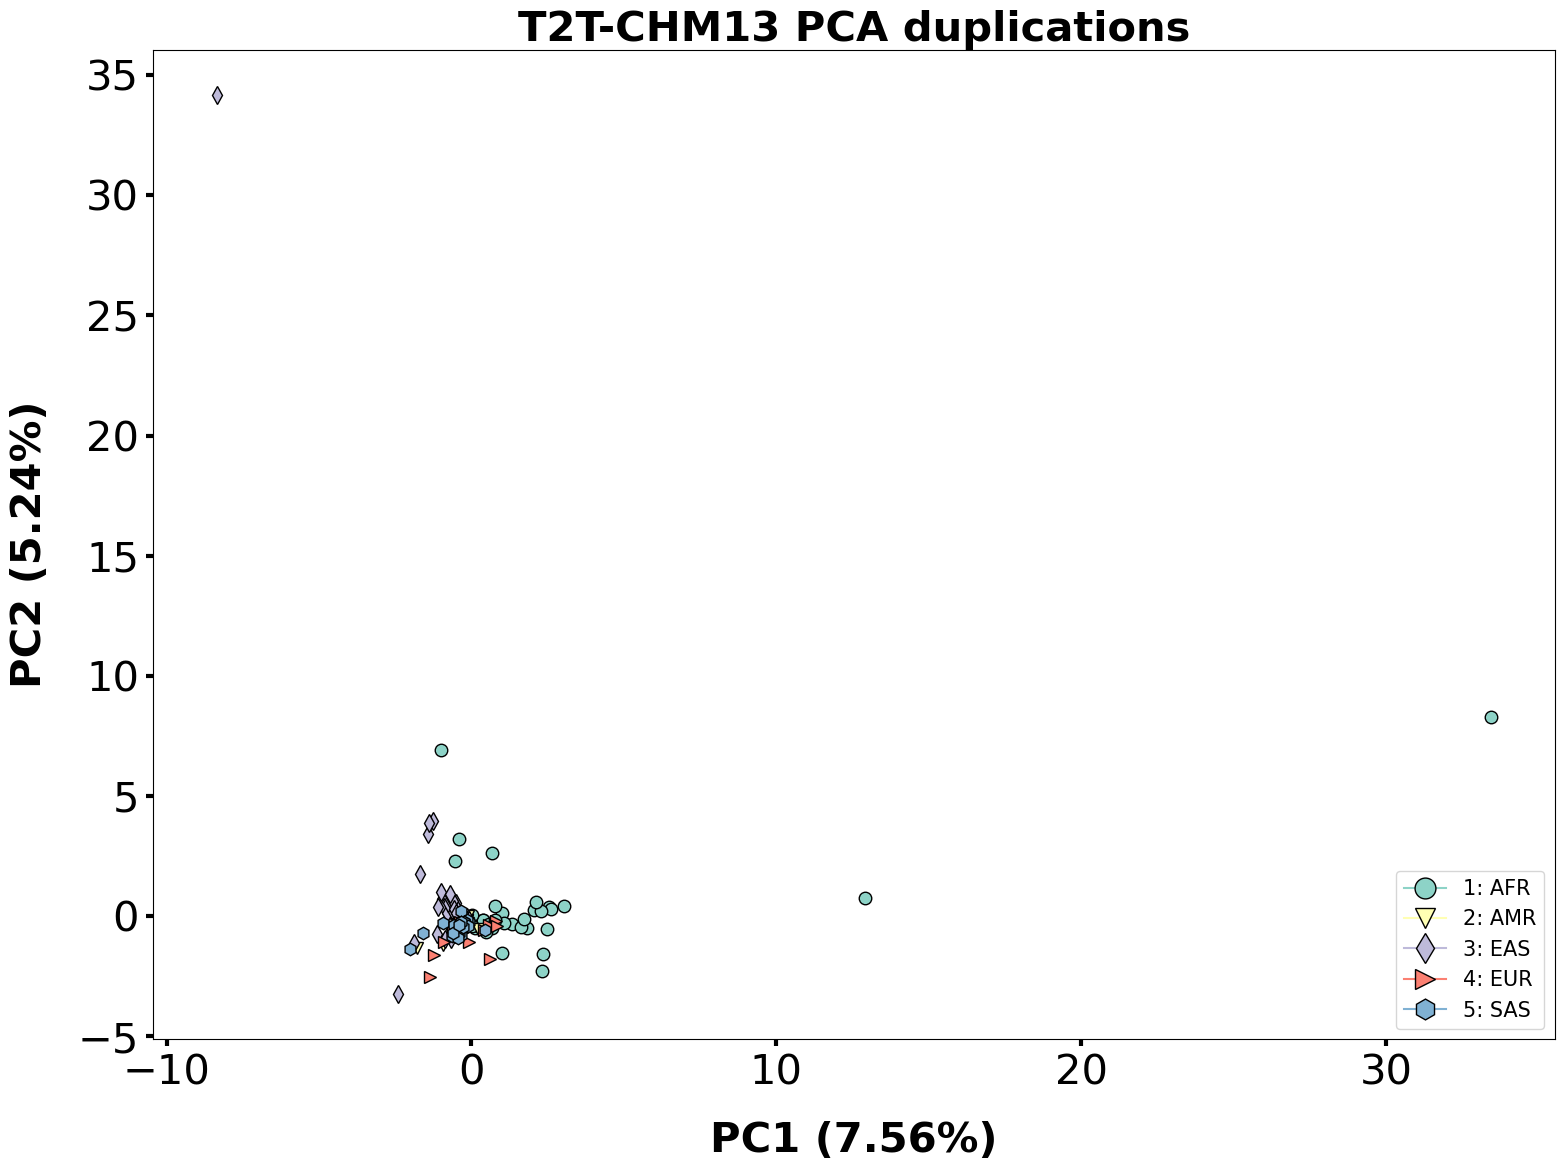

In [30]:
### Duplications
data_chm13_deletions = data_chm13[(data_chm13[data_chm13.columns[:]]>=2).all(axis=1)]
data_chm13_deletions = data_chm13_deletions[(data_chm13_deletions[data_chm13_deletions.columns[:]]<=4).all(axis=1)]
counts = data_chm13_deletions.T
counts = counts.sort_index()

features = anotation.merge(counts, left_index=True, right_index=True)
features = features.loc[:,["Superpopulation code"]]
features = features.sort_index()
features

x = StandardScaler().fit_transform(counts)
pca = PCA(n_components=10)
pca_results = pca.fit_transform(x)
df_pca= pd.DataFrame(pca_results,
                          columns=['component_1','component_2', 'component_3', 'component_4',
                                  'component_5',
                                  'component_6',
                                  'component_7',
                                  'component_8',
                                  'component_9',
                                   'component_10'
                                  ],
                          index=features.index)




df_pca = features.merge(df_pca, left_index=True, right_index=True)


#components = [1,2,3,4,5,6,7,8,9,10]

#combinations_components = list(combinations(components,2))
#for i in combinations_components:
#    plot_scatter_cluster_shape(data=df_pca, abscissa='component_'+str(i[0]), ordinate='component_'+str(i[1]), label_horizontal='PC '+ str(i[0]), label_vertical='PC '+str(i[1]), factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
    #print(str(i[0]))

plot_scatter_cluster_shape(data=df_pca, abscissa='component_1', ordinate='component_2', label_horizontal='PC1 (7.56%)', label_vertical='PC2 (5.24%)', factor='Superpopulation code', fonts=define_font_properties(), colors=define_color_properties(), legend=True)
plt.title("T2T-CHM13 PCA duplications", size=30, fontweight="bold")

plt.savefig('../plots/t2t_pca_duplications_pc12.png', transparent=True)

<h2> Vst 

In [31]:
####
data_chm13_ = features.merge(data_chm13.T, left_index=True, right_index=True)
data_chm13_ = data_chm13_.sort_values(by='Superpopulation code')
data_chm13_.to_csv('../data/input_dapc_t2t_hprc.csv')

####### Groupby regions #######
dt_group = data_chm13_.groupby('Superpopulation code')

dt_groupped = []
regions = features['Superpopulation code'].unique()
regions.sort()
for i in regions:
    dt_groupped.append(dt_group.get_group(str(i)))
    

#### Names to pair-population
regions = data_chm13_['Superpopulation code'].unique()
regions.sort()

combination_names = []
for i in list(combinations(regions,2)):
    combination_names.append(i[0]+str('-')+i[1])
    
for j in dt_groupped:
    j.drop(columns=['Superpopulation code'], inplace=True)



/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/914756806.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  j.drop(columns=['Superpopulation code'], inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/914756806.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  j.drop(columns=['Superpopulation code'], inplace=True)
/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_71065/914756806.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

In [32]:
data_chm13_

,Superpopulation code,0,1,2,3,4,5,6,7,8,...,12724,12725,12726,12727,12728,12729,12730,12731,12732,12733
HG02717,AFR,2.0,1.000000,2.0,2.0,1.0,0.571429,1.000000,2.0,2.000000,...,2.0,1.00,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0
NA19036,AFR,2.0,1.000000,2.0,2.0,1.0,1.000000,1.000000,2.0,0.666667,...,2.0,1.00,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
NA19043,AFR,2.0,1.142857,2.0,2.0,2.0,0.000000,1.500000,2.0,1.000000,...,2.0,1.25,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
HG02723,AFR,2.0,1.000000,1.0,2.0,2.0,0.333333,1.666667,2.0,1.250000,...,2.0,1.00,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0
NA19159,AFR,2.0,0.000000,1.0,2.0,1.0,1.000000,2.000000,2.0,2.333333,...,2.0,0.00,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HG02738,SAS,2.0,2.000000,2.0,2.0,2.0,0.833333,1.600000,2.0,1.000000,...,2.0,0.00,2.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0
HG02735,SAS,1.0,1.000000,2.0,2.0,2.0,1.090909,1.666667,2.0,1.000000,...,1.0,2.00,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0
NA21110,SAS,2.0,1.000000,0.0,2.0,2.0,1.142857,1.000000,2.0,1.000000,...,2.0,2.00,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0
HG02602,SAS,2.0,2.000000,2.0,2.0,2.0,0.333333,1.000000,2.0,1.000000,...,2.0,2.00,2.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0


In [33]:
## VST for pair-population
vst_dt = []

combination_regions = list(combinations([0,1,2,3,4],2))
for region in combination_regions:
        statistic = vst_function((dt_groupped[region[0]]), (dt_groupped[region[1]]))
        vst_dt.append(statistic)

vst_dt = pd.DataFrame(vst_dt).set_axis(combination_names)
vst_dt

,0,1,2,3,4,5,6,7,8,9,...,12724,12725,12726,12727,12728,12729,12730,12731,12732,12733
AFR-AMR,0.000003,0.012553,0.137251,0.006500,0.158643,0.218189,0.111041,0.008993,0.099078,0.024063,...,0.000710,0.176019,0.060543,0.122586,0.013953,0.019311,0.066073,NaN,0.088410,0.023214
AFR-EAS,0.000165,0.010523,0.051039,0.007086,0.219711,0.071248,0.140978,0.009099,0.000366,0.046161,...,0.007086,0.002566,0.038204,0.219860,NaN,0.000128,0.007817,NaN,0.007989,0.001317
AFR-EUR,0.004396,0.018993,0.136664,0.005176,0.170316,0.138362,0.026575,0.001422,0.000745,0.027315,...,0.157244,0.163300,0.065641,0.149704,NaN,0.055574,0.037215,NaN,0.028023,0.000018
AFR-SAS,0.001742,0.007147,0.117489,0.005831,0.187919,0.164946,0.066490,0.017885,0.046989,0.017857,...,0.012401,0.058421,0.019908,0.215935,0.017857,0.041083,0.004404,NaN,0.033254,0.009036
AMR-EAS,0.000120,0.000129,0.025253,NaN,0.025556,0.037000,0.004268,0.034564,0.107484,0.005597,...,0.012639,0.250651,0.179719,0.019821,0.012639,0.026423,0.031759,NaN,0.117068,0.033639
AMR-EUR,0.004770,0.001109,0.000046,NaN,0.019653,0.004890,0.025552,0.002839,0.084492,0.001067,...,0.132693,0.000604,0.009690,0.000881,0.009690,0.022078,0.003405,NaN,0.021237,0.018587
AMR-SAS,0.001664,0.000890,0.000319,NaN,0.021746,0.007599,0.008710,0.048919,0.016104,0.000422,...,0.007083,0.038038,0.012199,0.010178,0.000206,0.008622,0.040347,NaN,0.134565,0.001043
EAS-EUR,0.006618,0.001931,0.025121,NaN,NaN,0.012570,0.042212,0.017632,0.002255,0.001709,...,0.185185,0.239688,0.176471,0.012436,NaN,0.077096,0.013811,NaN,0.062259,0.001709
EAS-SAS,0.000940,0.000325,0.018697,NaN,NaN,0.013390,0.022722,0.002241,0.056639,0.009139,...,0.033069,0.097330,0.100669,0.002478,0.016340,0.053857,0.000384,NaN,0.015392,0.014440
EUR-SAS,0.012825,0.004223,0.000164,NaN,NaN,0.000075,0.006610,0.032284,0.043115,0.002822,...,0.085952,0.042304,0.023364,0.005380,0.012821,0.001661,0.019989,NaN,0.098361,0.007105


In [34]:
filtering_vst = pd.DataFrame(vst_dt)>=0.2
filtering_vst = filtering_vst.loc[:, filtering_vst.any()]
#filtering_vst = filtering_vst.set_axis(combination_names)
filtering_vst 

,4,5,12,19,23,26,49,63,68,75,...,12638,12670,12674,12696,12713,12720,12721,12722,12725,12727
AFR-AMR,False,True,True,True,True,True,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
AFR-EAS,True,False,False,True,False,True,True,False,False,True,...,False,True,True,True,False,True,False,True,False,True
AFR-EUR,False,False,True,True,False,False,False,True,True,True,...,False,False,False,True,False,False,False,False,False,False
AFR-SAS,False,False,False,True,False,False,False,False,False,True,...,False,True,False,True,False,False,False,False,False,True
AMR-EAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
AMR-EUR,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
AMR-SAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
EAS-EUR,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
EAS-SAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
EUR-SAS,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
## Coordinates anotation 
vst_dt = vst_dt.T
vst_dt.insert (0, 'Chromosome', chm13['Chromosome'])
vst_dt.insert (1, 'Start', chm13['Start'])
vst_dt.insert (2, 'End', chm13['End'])
#vst_dt.insert (3, 'Type', cnv['Type'])
vst_dt = vst_dt.round(5)
vst_dt_chm13 = vst_dt.replace(np.NaN, 0)
#vst_dt.to_csv('../data/vst_results_grch37.csv', index=False)
#vst_dt_chm13['Chromosome'] = 'chr' + vst_dt_chm13['Chromosome'].astype(str)
vst_dt_chm13['Start'] = vst_dt_chm13['Start'].astype(int)
vst_dt_chm13['End'] = vst_dt_chm13['End'].astype(int)
vst_dt_chm13

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
0,chr1,736,3272,0.00000,0.00016,0.00440,0.00174,0.00012,0.00477,0.00166,0.00662,0.00094,0.01282
1,chr1,24123,26129,0.01255,0.01052,0.01899,0.00715,0.00013,0.00111,0.00089,0.00193,0.00033,0.00422
2,chr1,34674,134000,0.13725,0.05104,0.13666,0.11749,0.02525,0.00005,0.00032,0.02512,0.01870,0.00016
3,chr1,139890,140991,0.00650,0.00709,0.00518,0.00583,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
4,chr1,151553,153659,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,chr9,150493245,150494904,0.01931,0.00013,0.05557,0.04108,0.02642,0.02208,0.00862,0.07710,0.05386,0.00166
12730,chr9,150539980,150547555,0.06607,0.00782,0.03721,0.00440,0.03176,0.00341,0.04035,0.01381,0.00038,0.01999
12731,chr9,150547891,150549071,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
12732,chr9,150549961,150551513,0.08841,0.00799,0.02802,0.03325,0.11707,0.02124,0.13456,0.06226,0.01539,0.09836


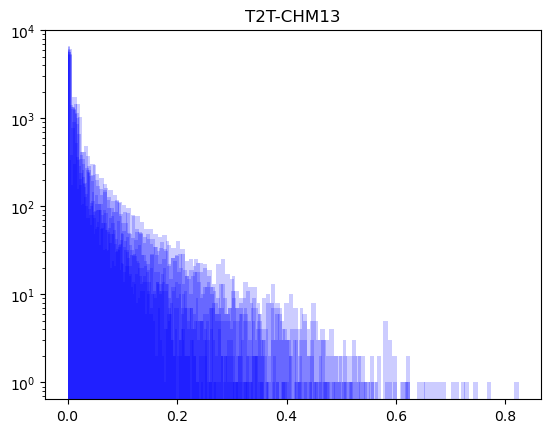

In [36]:
#sns.set_palette("bright")
for i in vst_dt_grch37.iloc[:,4:27].columns:
    plt.hist(vst_dt_grch37[i], bins=100, alpha=0.2, log=True, color="blue")
    plt.title('T2T-CHM13')
    plt.savefig('../plots/t2t_vst_values_distribution.png', transparent=True)

In [37]:
vst_dt_filtering_location = vst_dt_chm13.iloc[filtering_vst.columns]
vst_dt_filtering_location#[vst_dt_filtering_location['chr'] == '8'].sort_values(by='WestEurasia-Oceania', ascending=False).head(50)

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
4,chr1,151553,153659,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000
5,chr1,156352,344468,0.21819,0.07125,0.13836,0.16495,0.03700,0.00489,0.00760,0.01257,0.01339,0.00007
12,chr1,878859,969390,0.22657,0.16643,0.34143,0.16634,0.01518,0.02553,0.00812,0.08516,0.00088,0.06765
19,chr1,1528634,1531464,0.28902,0.28314,0.24428,0.21469,0.00935,0.00000,0.03102,0.00759,0.00914,0.02604
23,chr1,1879931,1881904,0.24342,0.16653,0.00416,0.10716,0.00618,0.18165,0.02620,0.10686,0.00608,0.06728
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12720,chr9,149969120,149971857,0.00830,0.28687,0.09020,0.11882,0.19624,0.04220,0.06368,0.06993,0.04005,0.00372
12721,chr9,149976431,149978736,0.20362,0.00024,0.00284,0.04626,0.25925,0.17457,0.08109,0.00397,0.07402,0.03428
12722,chr9,150037720,150039789,0.11425,0.29998,0.08994,0.13357,0.16209,0.00150,0.01809,0.10180,0.07025,0.00594
12725,chr9,150283675,150284902,0.17602,0.00257,0.16330,0.05842,0.25065,0.00060,0.03804,0.23969,0.09733,0.04230


In [38]:
vst_dt_filtered = vst_dt_chm13.iloc[filtering_vst.T.index]
#vst_dt_filtered.to_csv('../data/vst_candidates_grch37.csv', index=False) 
vst_chm13 = vst_dt_filtered
vst_t2t = vst_dt_filtered
vst_t2t.iloc[:,0:3].to_csv('../data/vst_candidates_coordinate_t2t.bed', sep='\t', header=False, index=False)

In [39]:
vst_dt_sb = vst_dt_filtered.drop(columns=['Chromosome', 'Start','End'])
data_chm13_.drop(columns=['Superpopulation code'], inplace=True)
data_chm13_ = data_chm13_.T.iloc[vst_dt_filtered.index]
data_chm13_

,HG02717,NA19036,NA19043,HG02723,NA19159,HG02668,HG02647,HG02630,HG02622,HG02615,...,HG03669,HG03654,HG03492,HG03239,HG03017,HG02738,HG02735,NA21110,HG02602,NA21144
4,1.000000,1.0,2.00,2.000000,1.0,2.0,2.000000,0.000000,1.000000,1.000000,...,2.000000,2.000000,2.0,2.0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
5,0.571429,1.0,0.00,0.333333,1.0,1.0,0.666667,0.777778,1.166667,1.333333,...,0.166667,1.000000,1.0,0.8,0.571429,0.833333,1.090909,1.142857,0.333333,1.222222
12,1.000000,1.0,1.00,2.000000,1.0,0.0,1.000000,1.000000,0.750000,1.000000,...,0.000000,2.000000,2.0,1.0,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000
19,1.000000,1.0,2.00,2.000000,0.0,1.0,2.000000,1.000000,1.000000,1.000000,...,2.000000,2.000000,2.0,2.0,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
23,1.000000,2.0,1.00,2.000000,1.0,1.0,1.000000,1.333333,1.200000,1.000000,...,2.000000,2.000000,2.0,1.0,2.000000,1.333333,2.000000,1.500000,1.000000,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12720,2.000000,2.0,1.00,2.000000,2.0,2.0,2.000000,2.000000,2.500000,2.000000,...,2.000000,1.666667,1.0,2.0,2.000000,1.666667,1.166667,1.000000,2.000000,1.800000
12721,2.000000,2.0,1.00,2.000000,3.0,2.0,1.000000,1.000000,2.000000,2.000000,...,0.000000,2.000000,2.0,1.0,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000
12722,1.000000,1.0,1.00,1.750000,1.0,2.0,1.000000,1.000000,3.000000,1.000000,...,1.000000,1.000000,1.0,1.0,2.000000,1.000000,1.500000,0.000000,1.000000,0.000000
12725,1.000000,1.0,1.25,1.000000,0.0,2.0,0.000000,1.250000,1.000000,2.000000,...,2.000000,2.000000,1.0,2.0,1.500000,0.000000,2.000000,2.000000,2.000000,0.000000


In [40]:
#vst_chm13.iloc[:,0:3].to_csv('../data/vst_candidates_coordinates_t2t.bed', sep='\t', header=False, index=False)

vst_grch37#.to_csv('../data/grch38_vst.csv')
vst_t2t.to_csv('../data/t2t_vst.csv')

## Anotation of genes T2T

In [43]:
## Anotations
vst_dt_filtered_ranges = PyRanges(vst_dt_filtered)
t2t_genes = pd.read_csv('../data/annotation_files/T2T-chm13-catLiftOffGenes.csv')
t2t_genes.columns = ['Chromosome', 'Start', 'End', 'name', 'score', 'strand',
       'thickStart', 'thickEnd', 'reserved', 'blockCount', 'blockSizes',
       'chromStarts', 'name2', 'cdsStartStat', 'cdsEndStat', 'exonFrames',
       'txId', 'type', 'geneName', 'geneType', 'sourceGene',
       'sourceTranscript', 'alignmentId', 'alternativeSourceTranscripts',
       'Paralogy', 'UnfilteredParalogy', 'collapsedGeneIds',
       'collapsedGeneNames', 'frameshift', 'exonAnnotationSupport',
       'intronAnnotationSupport', 'transcriptClass', 'transcriptModes',
       'validStart', 'validStop', 'properOrf', 'extra_paralog']
t2t_genes = t2t_genes[['Chromosome', 'Start', 'End', 'name2']]
t2t_genes = PyRanges(t2t_genes)

t2tchm13_ranges = PyRanges(chm13)
vst_dt_filtered_ranges
chm13

/var/folders/05/4pfxtbrs5459ytz3j1jhcgt00000gn/T/ipykernel_43126/1939203665.py:3: DtypeWarning: Columns (23,36) have mixed types. Specify dtype option on import or set low_memory=False.
  t2t_genes = pd.read_csv('../data/annotation_files/T2T-chm13-catLiftOffGenes.csv')


,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,chr1,736,3272,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2536.0
1,chr1,24123,26129,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,2.0,2006.0
2,chr1,34674,134000,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,99326.0
3,chr1,139890,140991,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1101.0
4,chr1,151553,153659,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,chr9,150493245,150494904,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1659.0
12730,chr9,150539980,150547555,1.0,2.0,2.000000,2.0,1.000000,2.0,0.0,...,1.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,0.0,7575.0
12731,chr9,150547891,150549071,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1180.0
12732,chr9,150549961,150551513,2.0,2.0,2.000000,0.0,1.000000,2.0,2.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1552.0


In [44]:
vst_dt_filtered_ranges

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
0,chr1,151553,153659,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000
1,chr1,156352,344468,0.21819,0.07125,0.13836,0.16495,0.03700,0.00489,0.00760,0.01257,0.01339,0.00007
2,chr1,878859,969390,0.22657,0.16643,0.34143,0.16634,0.01518,0.02553,0.00812,0.08516,0.00088,0.06765
3,chr1,1528634,1531464,0.28902,0.28314,0.24428,0.21469,0.00935,0.00000,0.03102,0.00759,0.00914,0.02604
4,chr1,1879931,1881904,0.24342,0.16653,0.00416,0.10716,0.00618,0.18165,0.02620,0.10686,0.00608,0.06728
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1125,chr22,47874803,47878221,0.00178,0.50247,0.02810,0.15418,0.49524,0.02058,0.14368,0.34291,0.17947,0.05243
1126,chr22,49532267,49534069,0.25798,0.04614,0.16887,0.06659,0.07710,0.01170,0.08874,0.03093,0.00021,0.03732
1127,chr22,49707802,49717453,0.23339,0.34555,0.05940,0.11152,0.01827,0.09410,0.02881,0.18352,0.08844,0.01842
1128,chr22,50533379,50535768,0.00010,0.05728,0.03984,0.00015,0.07812,0.04984,0.00069,0.24137,0.07534,0.07453


In [45]:
#Genes
grch37_coordinates_genes = vst_dt_filtered_ranges.nearest(t2t_genes)
grch37_coordinates_genes = grch37_coordinates_genes.as_df()
grch37_coordinates_genes = grch37_coordinates_genes[grch37_coordinates_genes['Distance'] <1 ]
#grch37_coordinates_genes.to_csv('../data/T2T_all_cnvs_genes_differentiated_by_Vst.csv')
grch37_coordinates_genes

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS,Start_b,End_b,name2,Distance
0,chr1,151553,153659,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000,152394,205163,AL669831.1,0
1,chr1,156352,344468,0.21819,0.07125,0.13836,0.16495,0.03700,0.00489,0.00760,0.01257,0.01339,0.00007,152394,205163,AL669831.1,0
2,chr1,878859,969390,0.22657,0.16643,0.34143,0.16634,0.01518,0.02553,0.00812,0.08516,0.00088,0.06765,884060,904534,ATAD3C,0
3,chr1,1528634,1531464,0.28902,0.28314,0.24428,0.21469,0.00935,0.00000,0.03102,0.00759,0.00914,0.02604,1485929,1620370,PRKCZ,0
4,chr1,1879931,1881904,0.24342,0.16653,0.00416,0.10716,0.00618,0.18165,0.02620,0.10686,0.00608,0.06728,1865578,1920914,PLCH2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,chr22,43913624,43915357,0.10541,0.27234,0.04054,0.01854,0.04401,0.01459,0.03855,0.10401,0.16046,0.00554,43892279,43990288,MPPED1,0
1108,chr22,45223094,45225383,0.02087,0.06172,0.23140,0.25339,0.01056,0.16975,0.18481,0.12466,0.13717,0.00000,45185983,45346192,PRR5-ARHGAP8,0
1109,chr22,45643326,45645731,0.22531,0.05654,0.20696,0.08111,0.09191,0.00969,0.09727,0.09453,0.00343,0.11494,45617507,45648274,NUP50-DT,0
1110,chr22,50533379,50535768,0.00010,0.05728,0.03984,0.00015,0.07812,0.04984,0.00069,0.24137,0.07534,0.07453,50520027,50560899,TTLL8,0


In [46]:
dt = []
for index, row in grch37_coordinates_genes.iterrows():
    if row['AFR-AMR'] > 0.2 and row['AMR-EAS'] < 0.1 and row['AMR-SAS'] < 0.1 and row['EUR-SAS'] and row['AMR-EUR'] < 0.1:
        dt.append([row['Chromosome'], row['Start'],row['End'],row['name2'],row['AFR-AMR'], 'Africa'])
        
    if row['AFR-AMR'] > 0.2 and row['AFR-EAS'] < 0.1 and row['AFR-EAS'] < 0.1 and row['AFR-SAS']:
        dt.append([row['Chromosome'], row['Start'],row['End'],row['name2'], row['AFR-AMR'], 'America'])
        
    if row['EAS-SAS'] > 0.2 and row['AFR-SAS'] < 0.1 and row['AMR-SAS'] < 0.1 and row['EUR-SAS']:
        dt.append([row['Chromosome'], row['Start'],row['End'], row['name2'],row['EAS-SAS'], 'EastAsia'])

    if row['EAS-SAS'] > 0.2 and row['AFR-EAS'] < 0.1 and row['AMR-EAS'] < 0.1 and row['EAS-EUR']:
        dt.append([row['Chromosome'], row['Start'],row['End'], row['name2'],row['EAS-SAS'], 'SouthAsia'])
    
    if row['AFR-EUR'] > 0.2 and row['AFR-AMR'] < 0.1 and row['AFR-EAS'] < 0.1 and row['AFR-SAS'] < 0.1:
        dt.append([row['Chromosome'], row['Start'],row['End'], row['name2'],row['AFR-EUR'], 'Europe'])



In [47]:
#Table 
d = {'Data': ['Significan differentiated CNVs', 'Differentiate CNVs in genes'],
     'Africa-America': [len(vst_dt_filtered[vst_dt_filtered['AFR-AMR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-AMR'] > 0.2])
                       ],
     'Africa-EastAsia': [len(vst_dt_filtered[vst_dt_filtered['AFR-EAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-EAS'] > 0.2])
                       ],
     'Africa-SouthAsia': [len(vst_dt_filtered[vst_dt_filtered['AFR-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-SAS'] > 0.2])
                       ],
     'Africa-Europe': [len(vst_dt_filtered[vst_dt_filtered['AFR-EUR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AFR-EUR'] > 0.2])
                       ],
     'America-EastAsia': [len(vst_dt_filtered[vst_dt_filtered['AMR-EAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AMR-EAS'] > 0.2])
                       ],
     'America-SouthAsia': [len(vst_dt_filtered[vst_dt_filtered['AMR-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AMR-SAS'] > 0.2])
                       ],
     'America-Europe': [len(vst_dt_filtered[vst_dt_filtered['AMR-EUR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['AMR-EUR'] > 0.2])
                       ],
     'EastAsia-SouthAsia': [len(vst_dt_filtered[vst_dt_filtered['EAS-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['EAS-SAS'] > 0.2])
                       ],
     'EastAsia-Europe': [len(vst_dt_filtered[vst_dt_filtered['EAS-EUR']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['EAS-EUR'] > 0.2])
                       ],
     'SouthAsia-Europe': [len(vst_dt_filtered[vst_dt_filtered['EUR-SAS']> 0.2])  ,len(grch37_coordinates_genes[grch37_coordinates_genes['EUR-SAS'] > 0.2])
                       ],
     
         }

df_map_t2t = pd.DataFrame(data=d)
df_map_t2t.T

,0,1
Data,Significan differentiated CNVs,Differentiate CNVs in genes
Africa-America,326,201
Africa-EastAsia,578,359
Africa-SouthAsia,346,199
Africa-Europe,366,236
America-EastAsia,172,98
America-SouthAsia,36,24
America-Europe,43,21
EastAsia-SouthAsia,137,88
EastAsia-Europe,313,197


In [48]:
df_map_grch38.T

,0,1
Data,Significan differentiated CNVs,Differentiate CNVs in genes
Africa-America,269,177
Africa-EastAsia,482,321
Africa-SouthAsia,318,212
Africa-Europe,384,249
America-EastAsia,151,95
America-SouthAsia,39,26
America-Europe,139,94
EastAsia-SouthAsia,114,82
EastAsia-Europe,287,191


In [69]:
# Statiscal analysis between Vst results from both assemblies
vst_t2t

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
4,chr1,151553,153659,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000
5,chr1,156352,344468,0.21819,0.07125,0.13836,0.16495,0.03700,0.00489,0.00760,0.01257,0.01339,0.00007
12,chr1,878859,969390,0.22657,0.16643,0.34143,0.16634,0.01518,0.02553,0.00812,0.08516,0.00088,0.06765
19,chr1,1528634,1531464,0.28902,0.28314,0.24428,0.21469,0.00935,0.00000,0.03102,0.00759,0.00914,0.02604
23,chr1,1879931,1881904,0.24342,0.16653,0.00416,0.10716,0.00618,0.18165,0.02620,0.10686,0.00608,0.06728
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12720,chr9,149969120,149971857,0.00830,0.28687,0.09020,0.11882,0.19624,0.04220,0.06368,0.06993,0.04005,0.00372
12721,chr9,149976431,149978736,0.20362,0.00024,0.00284,0.04626,0.25925,0.17457,0.08109,0.00397,0.07402,0.03428
12722,chr9,150037720,150039789,0.11425,0.29998,0.08994,0.13357,0.16209,0.00150,0.01809,0.10180,0.07025,0.00594
12725,chr9,150283675,150284902,0.17602,0.00257,0.16330,0.05842,0.25065,0.00060,0.03804,0.23969,0.09733,0.04230


In [50]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

In [51]:
for i in vst_t2t.columns[3:25]:
    print(i)
    print(stats.f_oneway(vst_t2t[i], vst_grch37[i]))
    

AFR-AMR
F_onewayResult(statistic=3.7683091245032916, pvalue=0.0523609537652931)
AFR-EAS
F_onewayResult(statistic=5.929254127381137, pvalue=0.014971142202475059)
AFR-EUR
F_onewayResult(statistic=3.3808348362187215, pvalue=0.06609440182787679)
AFR-SAS
F_onewayResult(statistic=1.6879473388239759, pvalue=0.19400897213176824)
AMR-EAS
F_onewayResult(statistic=0.020160305668534304, pvalue=0.8871033831827582)
AMR-EUR
F_onewayResult(statistic=54.0815552791575, pvalue=2.7067380987371693e-13)
AMR-SAS
F_onewayResult(statistic=2.907508208687813, pvalue=0.08831027364340321)
EAS-EUR
F_onewayResult(statistic=0.1973675536317461, pvalue=0.6568981598533707)
EAS-SAS
F_onewayResult(statistic=2.649010491125841, pvalue=0.10375868453105765)
EUR-SAS
F_onewayResult(statistic=14.889351285698606, pvalue=0.00011731220251214357)


In [52]:
t2t_anova = pd.melt(vst_t2t.iloc[:,3:30])
t2t_anova['assembly'] = 'T2T-CHM13'
grch37_anova = pd.melt(vst_grch37.iloc[:,3:30])
grch37_anova['assembly'] = 'GRCh38'
input_two_anova = pd.concat([grch37_anova, t2t_anova])
input_two_anova.columns = ['Populations', 'Vstvalue', 'Assembly']
input_two_anova

,Populations,Vstvalue,Assembly
0,AFR-AMR,0.15396,GRCh38
1,AFR-AMR,0.33836,GRCh38
2,AFR-AMR,0.22184,GRCh38
3,AFR-AMR,0.17556,GRCh38
4,AFR-AMR,0.29022,GRCh38
...,...,...,...
11295,EUR-SAS,0.00372,T2T-CHM13
11296,EUR-SAS,0.03428,T2T-CHM13
11297,EUR-SAS,0.00594,T2T-CHM13
11298,EUR-SAS,0.04230,T2T-CHM13


In [53]:
## ANOVA 

In [54]:
#perform two-way ANOVA
model = ols('Vstvalue ~ C(Populations) + C(Assembly) + C(Populations):C(Assembly)', data=input_two_anova).fit()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Populations),47.338076,9.0,456.501655,0.000000e+00
C(Assembly),0.011306,1.0,0.981216,3.219097e-01
C(Populations):C(Assembly),0.690098,9.0,6.654920,1.450932e-09
Residual,251.524023,21830.0,NaN,NaN


In [55]:
## T-test
vst_chm13
stats.ttest_ind.

SyntaxError: invalid syntax (969436257.py, line 3)

In [56]:
# ttest for each pair population
for i in vst_t2t.columns[3:24]:
    print(i)
    d = stats.ttest_ind(vst_t2t[i], vst_grch37[i])
    print(d)

AFR-AMR
TtestResult(statistic=1.941213312468083, pvalue=0.05236095376524456, df=2183.0)
AFR-EAS
TtestResult(statistic=2.4350059809744087, pvalue=0.01497114220246394, df=2183.0)
AFR-EUR
TtestResult(statistic=-1.838704662586884, pvalue=0.06609440182780481, df=2183.0)
AFR-SAS
TtestResult(statistic=1.299210275060956, pvalue=0.19400897213163637, df=2183.0)
AMR-EAS
TtestResult(statistic=-0.14198699119473823, pvalue=0.887103383182497, df=2183.0)
AMR-EUR
TtestResult(statistic=-7.354016268622031, pvalue=2.7067380987348237e-13, df=2183.0)
AMR-SAS
TtestResult(statistic=-1.705141697539481, pvalue=0.08831027364333363, df=2183.0)
EAS-EUR
TtestResult(statistic=-0.44426068206824953, pvalue=0.6568981598538853, df=2183.0)
EAS-SAS
TtestResult(statistic=1.62757810599855, pvalue=0.10375868453096904, df=2183.0)
EUR-SAS
TtestResult(statistic=-3.8586722179654807, pvalue=0.00011731220251204627, df=2183.0)


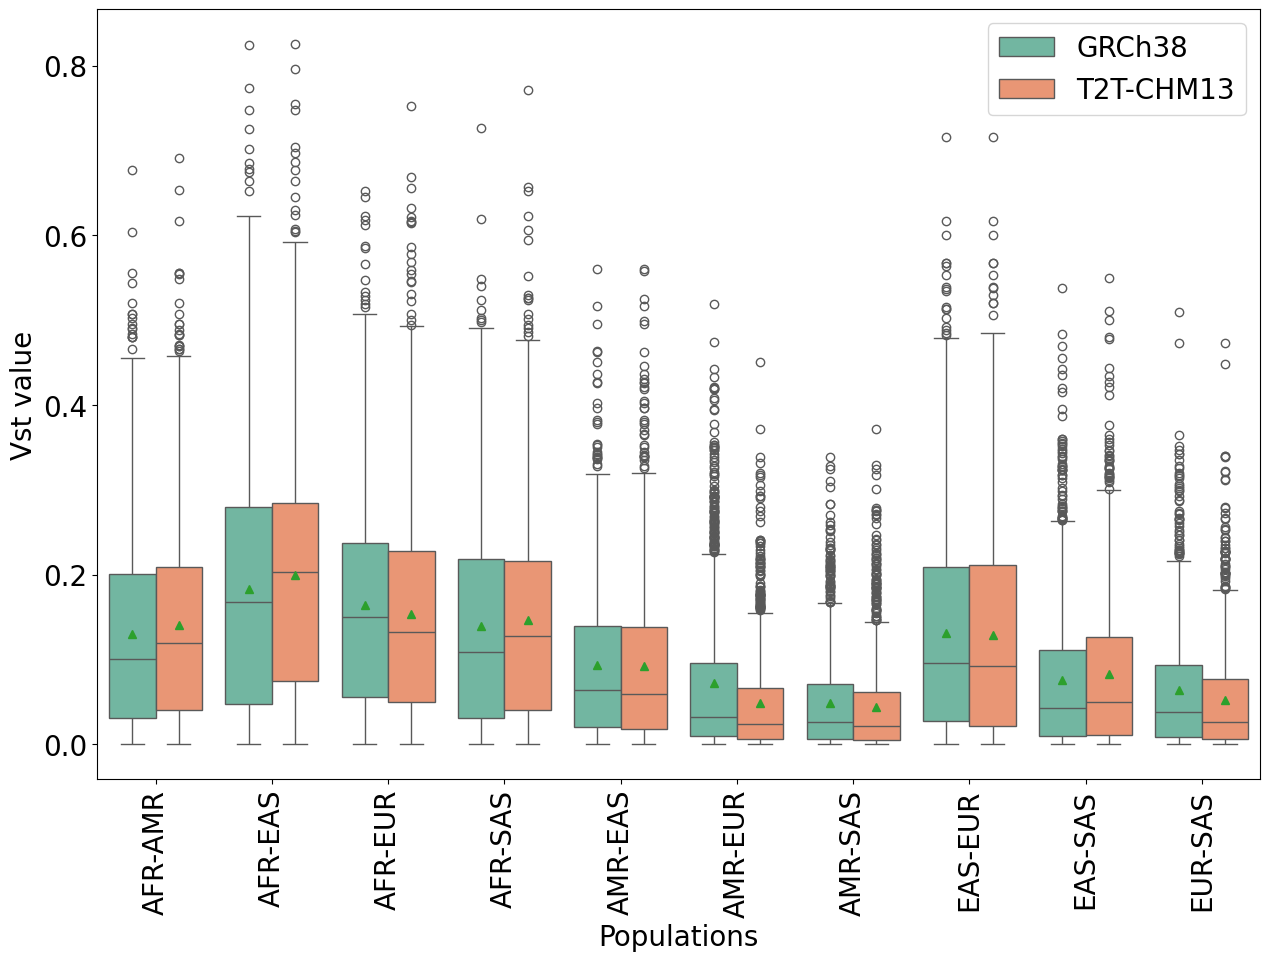

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,10))
ax = sns.boxplot(x='Populations',y='Vstvalue',data=input_two_anova,hue='Assembly', palette= "Set2", showmeans=True)
#ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.xticks(fontsize=20, rotation=90)
plt.yticks(fontsize=20)
plt.xlabel('Populations', fontsize=20)
plt.ylabel('Vst value', fontsize=20)
plt.legend(loc=1, prop={'size': 20})
plt.savefig('../plots/Figure3a.png', transparent=True, dpi=300, bbox_inches = "tight")
#sns.boxplot(input_boxplot, rot=90)

In [58]:
t2t_to_grch37 

NameError: name 't2t_to_grch37' is not defined

In [59]:
header_1 = ['Chromosome','Start', 'End', 'Original','Strain']
header_2 = ['Chromosome', 'Start' , 'End']
header_3 = ['Chromosome', 'Start' , 'End', 'Type']
header_4 = ['Chromosome','Start', 'End', 'Type','Strain']

grch37_to_t2t = pd.read_csv('/Users/luciabazan/Downloads/grch38_vst_candidates_to_t2t_coordinates.bed', sep='\t', names=header_1)
grch37_to_t2t_all = pd.read_csv('/Users/luciabazan/Downloads/grch38_cnvs_to_t2t_coordinates.bed', sep='\t', names=header_1)
grch37_to_t2t_all = PyRanges(grch37_to_t2t_all)

t2t_to_grch37 = pd.read_csv('/Users/luciabazan/Downloads/t2t_vst_candidates_to_grch38_coordinates.bed', sep='\t', names=header_1)
t2t_to_grch37 = PyRanges(t2t_to_grch37)

In [60]:
#### GRCh37 vst to T2T vst 
grch37_to_t2t = PyRanges(grch37_to_t2t)

In [61]:
vst_t2t_ranges = PyRanges(vst_t2t)
grch37_to_t2tchm13 = grch37_to_t2t.nearest(vst_t2t_ranges)
grch37_to_t2tchm13 = grch37_to_t2tchm13.as_df()

grch37_to_t2tchm13 = grch37_to_t2tchm13[grch37_to_t2tchm13['Distance'] < 2000]

## Getting original coordinates
grch37_to_t2tchm13[['Chromosome_old','coordinates_old']] = grch37_to_t2tchm13.Original.str.split(":", expand = True)
grch37_to_t2tchm13[['Start_old','End_old']] = grch37_to_t2tchm13.coordinates_old.str.split("-", expand = True)
grch37_to_t2tchm13['End_old'] = grch37_to_t2tchm13['End_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'] -1 
grch37_to_t2tchm13

,Chromosome,Start,End,Original,Strain,Start_b,End_b,AFR-AMR,AFR-EAS,AFR-EUR,...,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS,Distance,Chromosome_old,coordinates_old,Start_old,End_old
0,chr1,156352,344468,chr1:729843-914823,1,156352,344468,0.21819,0.07125,0.13836,...,0.00489,0.00760,0.01257,0.01339,0.00007,0,chr1,729843-914823,729842,914823
1,chr1,339156,339281,chr1:729843-914823,2,156352,344468,0.21819,0.07125,0.13836,...,0.00489,0.00760,0.01257,0.01339,0.00007,0,chr1,729843-914823,729842,914823
2,chr1,339218,339336,chr1:729843-914823,3,156352,344468,0.21819,0.07125,0.13836,...,0.00489,0.00760,0.01257,0.01339,0.00007,0,chr1,729843-914823,729842,914823
3,chr1,339403,339529,chr1:729843-914823,4,156352,344468,0.21819,0.07125,0.13836,...,0.00489,0.00760,0.01257,0.01339,0.00007,0,chr1,729843-914823,729842,914823
4,chr1,878859,969390,chr1:1444488-1534886,1,878859,969390,0.22657,0.16643,0.34143,...,0.02553,0.00812,0.08516,0.00088,0.06765,0,chr1,1444488-1534886,1444487,1534886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1242,chr22,43186321,43189332,chr22:42705441-42708446,1,43186321,43189332,0.23984,0.01709,0.22013,...,0.00000,0.00151,0.12819,0.15305,0.00141,0,chr22,42705441-42708446,42705440,42708446
1243,chr22,45223094,45225383,chr22:44739367-44741639,1,45223094,45225383,0.02087,0.06172,0.23140,...,0.16975,0.18481,0.12466,0.13717,0.00000,0,chr22,44739367-44741639,44739366,44741639
1244,chr22,45643326,45645731,chr22:45158838-45161242,1,45643326,45645731,0.22531,0.05654,0.20696,...,0.00969,0.09727,0.09453,0.00343,0.11494,0,chr22,45158838-45161242,45158837,45161242
1245,chr22,45742944,45746018,chr22:45257852-45260929,1,45742944,45745996,0.23685,0.17308,0.23545,...,0.01965,0.00042,0.05753,0.01852,0.02604,0,chr22,45257852-45260929,45257851,45260929


In [62]:
vst_grch37_ranges = grch37_to_t2tchm13.merge(vst_grch37, left_on=['Start_old','Chromosome'], right_on=['Start','Chromosome'])
vst_grch37_ranges

,Chromosome,Start_x,End_x,Original,Strain,Start_b,End_b,AFR-AMR_x,AFR-EAS_x,AFR-EUR_x,...,AFR-AMR_y,AFR-EAS_y,AFR-EUR_y,AFR-SAS_y,AMR-EAS_y,AMR-EUR_y,AMR-SAS_y,EAS-EUR_y,EAS-SAS_y,EUR-SAS_y
0,chr1,156352,344468,chr1:729843-914823,1,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
1,chr1,339156,339281,chr1:729843-914823,2,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
2,chr1,339218,339336,chr1:729843-914823,3,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
3,chr1,339403,339529,chr1:729843-914823,4,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
4,chr1,878859,969390,chr1:1444488-1534886,1,878859,969390,0.22657,0.16643,0.34143,...,0.22184,0.16136,0.33825,0.17075,0.01518,0.02553,0.00614,0.08516,0.00180,0.06136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,chr22,43186321,43189332,chr22:42705441-42708446,1,43186321,43189332,0.23984,0.01709,0.22013,...,0.24686,0.01976,0.22725,0.26858,0.13975,0.00000,0.00320,0.12819,0.16374,0.00295
535,chr22,45223094,45225383,chr22:44739367-44741639,1,45223094,45225383,0.02087,0.06172,0.23140,...,0.02054,0.06216,0.24072,0.26652,0.01056,0.16975,0.18706,0.12466,0.13905,0.00000
536,chr22,45643326,45645731,chr22:45158838-45161242,1,45643326,45645731,0.22531,0.05654,0.20696,...,0.22101,0.05391,0.20334,0.06944,0.09191,0.00969,0.10999,0.09453,0.00137,0.12582
537,chr22,45742944,45746018,chr22:45257852-45260929,1,45742944,45745996,0.23685,0.17308,0.23545,...,0.22157,0.15904,0.22139,0.20193,0.02486,0.01965,0.00030,0.05753,0.01947,0.02495


In [63]:
## correlation
from itertools import combinations
regions = ['AFR','AMR','EAS','EUR','SAS']
regions.sort()
combination_names = []
for i in list(combinations(regions,2)):
    combination_names.append(i[0]+str('-')+i[1])

In [64]:
vst_grch37_ranges

,Chromosome,Start_x,End_x,Original,Strain,Start_b,End_b,AFR-AMR_x,AFR-EAS_x,AFR-EUR_x,...,AFR-AMR_y,AFR-EAS_y,AFR-EUR_y,AFR-SAS_y,AMR-EAS_y,AMR-EUR_y,AMR-SAS_y,EAS-EUR_y,EAS-SAS_y,EUR-SAS_y
0,chr1,156352,344468,chr1:729843-914823,1,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
1,chr1,339156,339281,chr1:729843-914823,2,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
2,chr1,339218,339336,chr1:729843-914823,3,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
3,chr1,339403,339529,chr1:729843-914823,4,156352,344468,0.21819,0.07125,0.13836,...,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
4,chr1,878859,969390,chr1:1444488-1534886,1,878859,969390,0.22657,0.16643,0.34143,...,0.22184,0.16136,0.33825,0.17075,0.01518,0.02553,0.00614,0.08516,0.00180,0.06136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,chr22,43186321,43189332,chr22:42705441-42708446,1,43186321,43189332,0.23984,0.01709,0.22013,...,0.24686,0.01976,0.22725,0.26858,0.13975,0.00000,0.00320,0.12819,0.16374,0.00295
535,chr22,45223094,45225383,chr22:44739367-44741639,1,45223094,45225383,0.02087,0.06172,0.23140,...,0.02054,0.06216,0.24072,0.26652,0.01056,0.16975,0.18706,0.12466,0.13905,0.00000
536,chr22,45643326,45645731,chr22:45158838-45161242,1,45643326,45645731,0.22531,0.05654,0.20696,...,0.22101,0.05391,0.20334,0.06944,0.09191,0.00969,0.10999,0.09453,0.00137,0.12582
537,chr22,45742944,45746018,chr22:45257852-45260929,1,45742944,45745996,0.23685,0.17308,0.23545,...,0.22157,0.15904,0.22139,0.20193,0.02486,0.01965,0.00030,0.05753,0.01947,0.02495


In [65]:
## Table S4 
ls = []
for i in range(10):
    r = (stats.pearsonr(vst_grch37_ranges[combination_names[i]+str('_y')],vst_grch37_ranges[combination_names[i]+str('_x')] ))
    ls.append((combination_names[i], r.statistic , r.pvalue))
    d = pd.DataFrame(ls)
d.columns = ['Populations', 'r', 'pvalue']
d#.to_csv('../data/S4_table.csv')
d

,Populations,r,pvalue
0,AFR-AMR,0.840491,4.951262e-145
1,AFR-EAS,0.871924,1.150079e-168
2,AFR-EUR,0.767508,8.878965e-106
3,AFR-SAS,0.830782,9.387608e-139
4,AMR-EAS,0.891214,1.628047e-186
5,AMR-EUR,0.701282,5.768757e-81
6,AMR-SAS,0.884846,2.850836e-180
7,EAS-EUR,0.938909,6.436572e-251
8,EAS-SAS,0.918596,1.154730e-218
9,EUR-SAS,0.880468,3.441224e-176


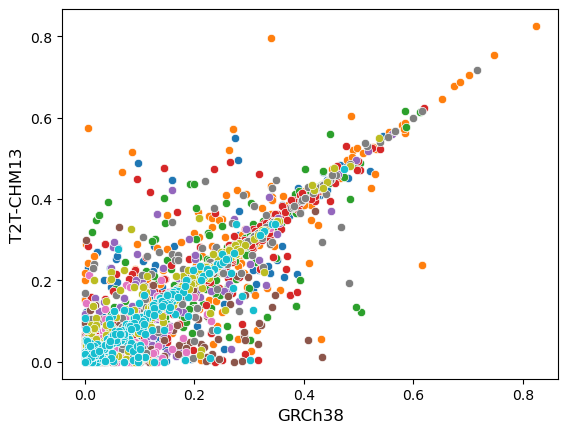

In [66]:
for i in range(10):
    #plt.figure() added for different figures
    #plt.scatter(vst_grch37[combination_names[i]+str('_y')],vst_grch37[combination_names[i]+str('_x')] )
    
    ax =  sns.scatterplot(data=vst_grch37_ranges, x=str(combination_names[i]+str('_y')), y=str(combination_names[i]+str('_x')))
    ax.set(xlabel='GRCh38', ylabel='T2T-CHM13')
    ax.set_xlabel('GRCh38', size = 12)
    ax.set_ylabel('T2T-CHM13', size = 12)
    #plt.xlabel("GRCh37")
    #plt.ylabel("T2T-CHM13")
    #plt.title("Mean R= 0.8833, mean pvalue=3.383E-13", size=15)
    #plt.savefig('../plots/Figure3b.png', transparent=True)
    
    

In [67]:
## ALL CNVS 

### GRCh37 all CNVs to T2T all CNVs 
vst_dt_t2t_ranges = PyRanges(vst_dt_chm13)
grch37_to_t2tchm13 = grch37_to_t2t_all.nearest(vst_dt_t2t_ranges)
grch37_to_t2tchm13 = grch37_to_t2tchm13.as_df()
grch37_to_t2tchm13  =grch37_to_t2tchm13[grch37_to_t2tchm13['Distance'] < 2]

## Getting vst values 
grch37_to_t2tchm13[['Chromosome_old','coordinates_old']] = grch37_to_t2tchm13.Original.str.split(":", expand = True)
grch37_to_t2tchm13[['Start_old','End_old']] = grch37_to_t2tchm13.coordinates_old.str.split("-", expand = True)

grch37_to_t2tchm13['End_old'] = grch37_to_t2tchm13['End_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'] -1 
grch37_to_t2tchm13

input_scatter_all_vst = grch37_to_t2tchm13.merge(vst_dt_grch37, left_on=['Start_old','Chromosome'], right_on=['Start','Chromosome'])
input_scatter_all_vst = input_scatter_all_vst.drop_duplicates(subset=['Start_b', 'End_b'])

input_scatter_all_vst

,Chromosome,Start_x,End_x,Original,Strain,Start_b,End_b,AFR-AMR_x,AFR-EAS_x,AFR-EUR_x,...,AFR-AMR_y,AFR-EAS_y,AFR-EUR_y,AFR-SAS_y,AMR-EAS_y,AMR-EUR_y,AMR-SAS_y,EAS-EUR_y,EAS-SAS_y,EUR-SAS_y
0,chr1,5525,134000,chr1:126242-707779,8,24123,26129,0.01255,0.01052,0.01899,...,0.00236,0.00010,0.00045,0.00423,0.00183,0.00133,0.00054,0.00016,0.00387,0.00387
2,chr1,36563,36705,chr1:126242-707779,13,34674,134000,0.13725,0.05104,0.13666,...,0.00236,0.00010,0.00045,0.00423,0.00183,0.00133,0.00054,0.00016,0.00387,0.00387
4,chr1,223078563,223110542,chr1:126242-707779,18,223102326,223104404,0.00000,0.00000,0.00000,...,0.00236,0.00010,0.00045,0.00423,0.00183,0.00133,0.00054,0.00016,0.00387,0.00387
5,chr1,139890,140991,chr1:713328-714478,1,139890,140991,0.00650,0.00709,0.00518,...,0.15396,0.21193,0.29407,0.18103,0.00526,0.08644,0.00468,0.06728,0.00001,0.05148
6,chr1,151553,154890,chr1:725044-728380,1,151553,153659,0.15864,0.21971,0.17032,...,0.07495,0.12673,0.09585,0.10833,0.02556,0.01965,0.02206,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9922,chr22,50851733,50853524,chr22:50343870-50345691,1,50851733,50853524,0.09842,0.09000,0.10786,...,0.10695,0.00098,0.00202,0.00250,0.18379,0.20499,0.10810,0.00046,0.00975,0.01484
9923,chr22,50942423,50944034,chr22:50433229-50434839,1,50942385,50944034,0.10303,0.09539,0.19071,...,0.16628,0.08639,0.18063,0.13117,0.02221,0.01108,0.00257,0.04626,0.01006,0.02145
9924,chr22,50999673,51003908,chr22:50490492-50494732,1,50999673,51003908,0.00000,0.01125,0.00000,...,0.00000,0.01117,0.00000,0.00000,0.00935,0.00000,0.00000,0.00759,0.00860,0.00000
9925,chr22,51139715,51150693,chr22:50629206-50640118,1,51136085,51158037,0.03755,0.00651,0.04830,...,0.00000,0.00370,0.01129,0.01710,0.00935,0.01321,0.02980,0.02016,0.00851,0.03018


In [68]:

## Table S5 

ls = []
for i in range(10):
    r = (stats.pearsonr(input_scatter_all_vst[combination_names[i]+str('_y')],input_scatter_all_vst[combination_names[i]+str('_x')] ))
    ls.append((combination_names[i], r.statistic , r.pvalue))
    d = pd.DataFrame(ls)
d.columns = ['Populations', 'r', 'pvalue']
ls = pd.DataFrame(ls)
ls


,0,1,2
0,AFR-AMR,0.763129,0.0
1,AFR-EAS,0.791253,0.0
2,AFR-EUR,0.741667,0.0
3,AFR-SAS,0.802636,0.0
4,AMR-EAS,0.805095,0.0
5,AMR-EUR,0.510942,0.0
6,AMR-SAS,0.726513,0.0
7,EAS-EUR,0.773639,0.0
8,EAS-SAS,0.796458,0.0
9,EUR-SAS,0.713063,0.0


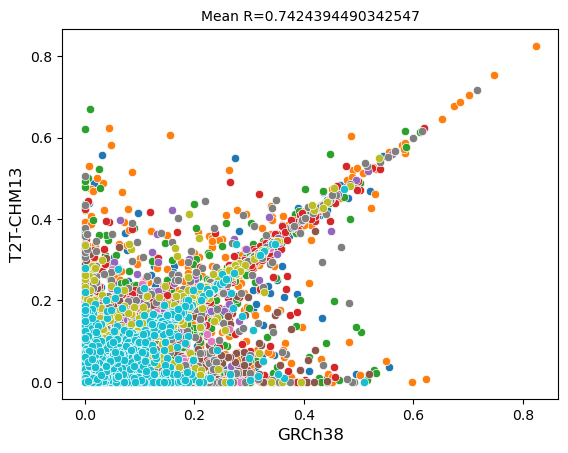

In [86]:
for i in range(10):
    #plt.figure() added for different figures
    #plt.scatter(vst_grch37[combination_names[i]+str('_y')],vst_grch37[combination_names[i]+str('_x')] )

    ax =  sns.scatterplot(data=input_scatter_all_vst, x=str(combination_names[i]+str('_y')), y=str(combination_names[i]+str('_x')))
    
    ax.set(xlabel='GRCh38', ylabel='T2T-CHM13')

    ax.set_xlabel('GRCh38', size = 12)
    ax.set_ylabel('T2T-CHM13', size = 12)
    #plt.xlabel("GRCh37")
    #plt.ylabel("T2T-CHM13")
    plt.title("Mean R="+str(ls[1].mean()), size=10)
    plt.savefig('../plots/Figure3b.png', transparent=True)
    
    
 ##### significant    

In [129]:
# Correlation of CNVs 

In [130]:
chm13_ranges = PyRanges(chm13)
### GRCh37 all CNVs to T2T all CNVs 
vst_dt_t2t_ranges = PyRanges(vst_dt_chm13)
grch37_to_t2tchm13 = grch37_to_t2t_all.nearest(chm13_ranges)
grch37_to_t2tchm13 = grch37_to_t2tchm13.as_df()
grch37_to_t2tchm13  =grch37_to_t2tchm13[grch37_to_t2tchm13['Distance'] < 2]

## Getting old CNVs 
grch37_to_t2tchm13[['Chromosome_old','coordinates_old']] = grch37_to_t2tchm13.Original.str.split(":", expand = True)
grch37_to_t2tchm13[['Start_old','End_old']] = grch37_to_t2tchm13.coordinates_old.str.split("-", expand = True)
grch37_to_t2tchm13['End_old'] = grch37_to_t2tchm13['End_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'] -1 



### GRCh38 coordinates to T2T
grch38_to_t2t_cnvs = grch37_to_t2tchm13.merge(cnv, left_on=['Start_old','Chromosome'], right_on=['Start','Chromosome'])
grch38_to_t2t_cnvs = grch38_to_t2t_cnvs.drop_duplicates(subset=['Start_b', 'End_b'])
grch38_to_t2t_cnvs


,Chromosome,Start_x,End_x,Original,Strain,Start_b,End_b,HG00097_x,HG00099_x,HG00126_x,...,NA20827_y,NA20850_y,NA20870_y,NA20905_y,NA21093_y,NA21102_y,NA21106_y,NA21110_y,NA21144_y,Length_y
0,chr1,5525,134000,chr1:126242-707779,8,24123,26129,1.0,2.0,2.000000,...,1.5,2.0,0.8,1.0,1.333333,1.0,1.500000,2.0,1.500000,581538.0
2,chr1,36563,36705,chr1:126242-707779,13,34674,134000,2.0,2.0,1.333333,...,1.5,2.0,0.8,1.0,1.333333,1.0,1.500000,2.0,1.500000,581538.0
4,chr1,223078563,223110542,chr1:126242-707779,18,223102326,223104404,2.0,2.0,2.000000,...,1.5,2.0,0.8,1.0,1.333333,1.0,1.500000,2.0,1.500000,581538.0
5,chr1,139890,140991,chr1:713328-714478,1,139890,140991,2.0,2.0,2.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,1151.0
6,chr1,151553,154890,chr1:725044-728380,1,151553,153659,2.0,2.0,2.000000,...,2.0,2.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.000000,3337.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9922,chr22,50851733,50853524,chr22:50343870-50345691,1,50851733,50853524,2.0,1.0,1.000000,...,2.0,2.0,1.0,1.0,1.000000,1.0,1.000000,1.0,1.000000,1822.0
9923,chr22,50942423,50944034,chr22:50433229-50434839,1,50942385,50944034,2.0,2.0,2.000000,...,2.0,2.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.000000,1611.0
9924,chr22,50999673,51003908,chr22:50490492-50494732,1,50999673,51003908,2.0,2.0,2.000000,...,2.0,2.0,2.0,2.0,2.000000,2.0,2.000000,2.0,2.000000,4241.0
9925,chr22,51139715,51150693,chr22:50629206-50640118,1,51136085,51158037,2.0,2.0,1.000000,...,2.0,2.0,2.0,2.0,2.000000,2.0,1.000000,2.0,2.000000,10913.0


In [131]:
chm13_ranges

,Chromosome,Start,End,HG00097,HG00099,HG00126,HG00128,HG00133,HG00140,HG00146,...,NA20827,NA20850,NA20870,NA20905,NA21093,NA21102,NA21106,NA21110,NA21144,Length
0,chr1,736,3272,1.0,2.0,2.000000,1.0,2.000000,1.0,1.0,...,2.0,2.0,2.00,1.0,2.0,2.000000,2.0,2.0,2.0,2536.0
1,chr1,24123,26129,1.0,2.0,2.000000,1.5,1.000000,2.0,2.0,...,1.0,2.0,2.00,2.0,1.0,1.000000,2.0,1.0,2.0,2006.0
2,chr1,34674,134000,2.0,2.0,1.333333,1.0,1.444444,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,0.0,2.0,99326.0
3,chr1,139890,140991,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,1101.0
4,chr1,151553,153659,2.0,2.0,2.000000,2.0,2.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,2106.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,chr22,51136085,51158037,2.0,2.0,1.000000,1.0,1.000000,0.0,2.0,...,2.0,1.0,1.00,2.0,1.0,1.666667,1.5,1.0,1.0,21952.0
12730,chr22,51193635,51195108,2.0,2.0,2.000000,2.0,1.000000,2.0,2.0,...,2.0,2.0,2.00,2.0,2.0,2.000000,2.0,2.0,2.0,1473.0
12731,chr22,51196249,51198088,2.0,2.0,2.000000,2.0,2.000000,2.0,1.5,...,2.0,2.0,1.25,2.0,1.0,2.000000,2.0,1.0,2.0,1839.0
12732,chr22,51313529,51314814,1.0,1.0,2.000000,2.0,2.000000,1.0,2.0,...,2.0,1.0,1.00,0.5,2.0,1.000000,0.0,1.0,1.0,1285.0


SignificanceResult(statistic=0.6566716944476549, pvalue=0.0)


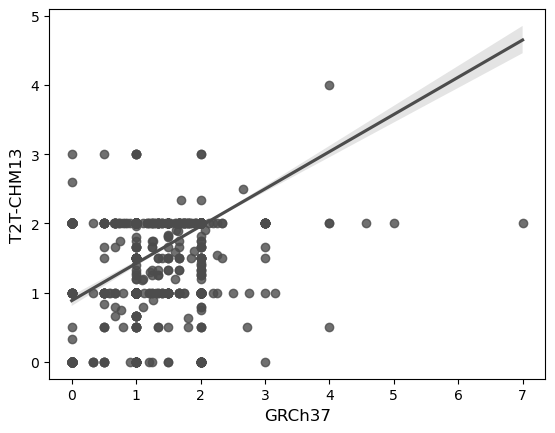

SignificanceResult(statistic=0.7288326087835243, pvalue=0.0)


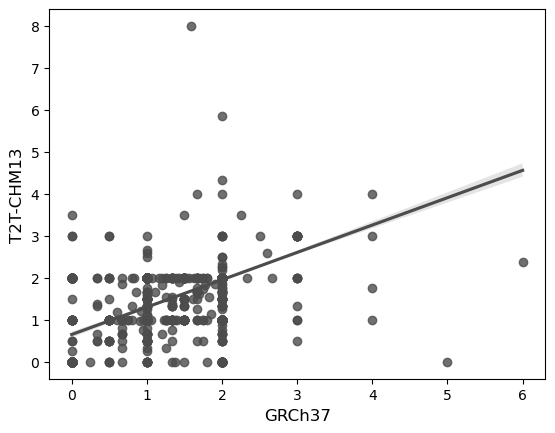

SignificanceResult(statistic=0.7229530138775478, pvalue=0.0)


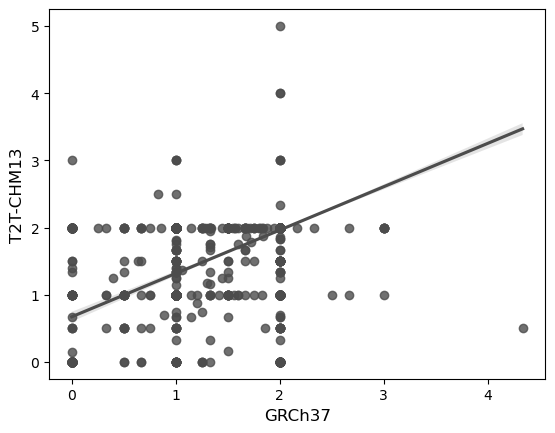

SignificanceResult(statistic=0.7294724657089563, pvalue=0.0)


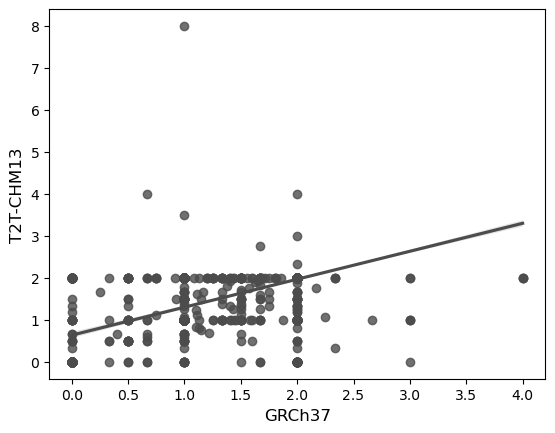

SignificanceResult(statistic=0.7286908534610791, pvalue=0.0)


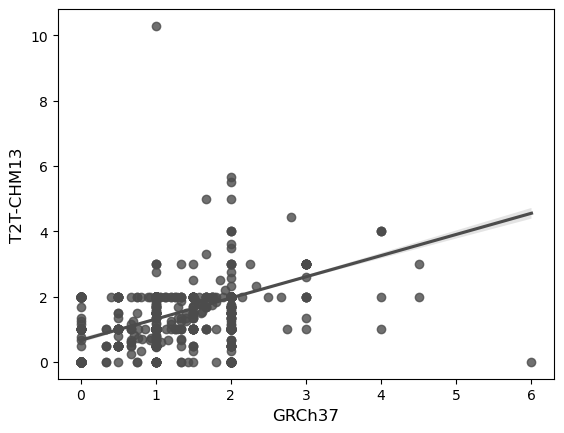

SignificanceResult(statistic=0.730015123430264, pvalue=0.0)


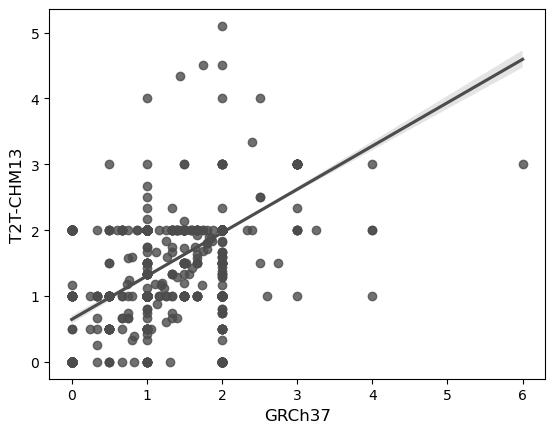

SignificanceResult(statistic=0.7230861611335873, pvalue=0.0)


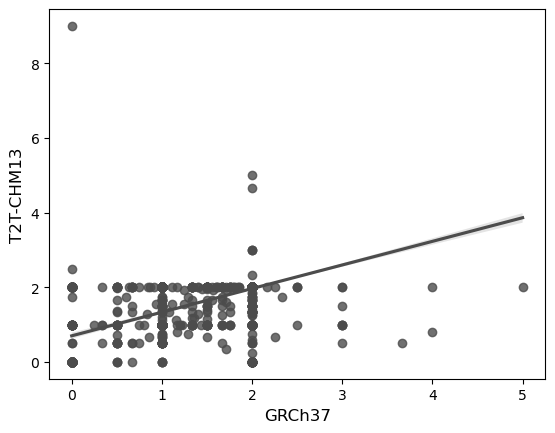

SignificanceResult(statistic=0.6615164079387968, pvalue=0.0)


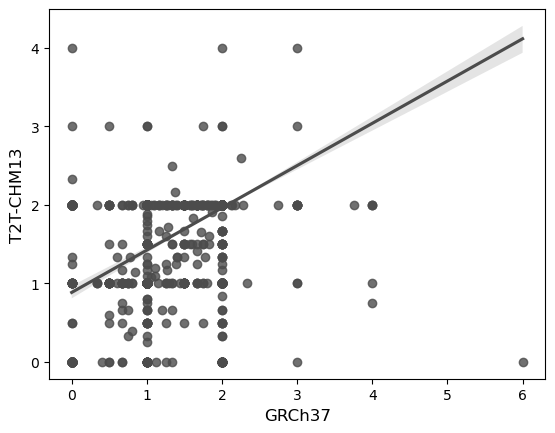

SignificanceResult(statistic=0.6793332562252304, pvalue=0.0)


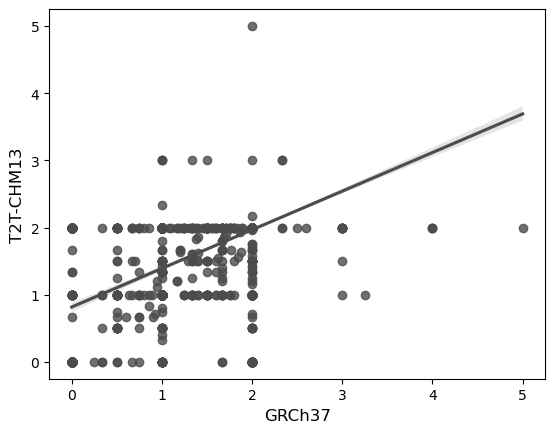

SignificanceResult(statistic=0.7276902219239506, pvalue=0.0)


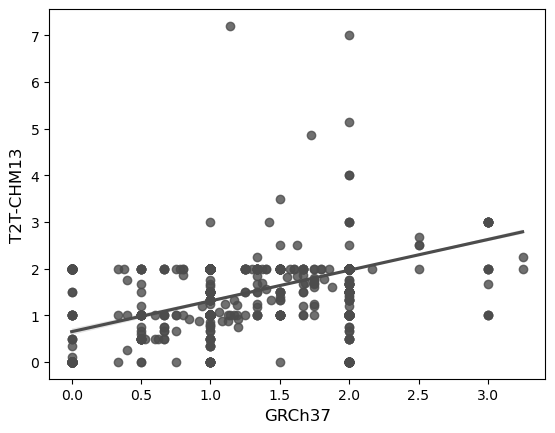

SignificanceResult(statistic=0.7243570704773977, pvalue=0.0)


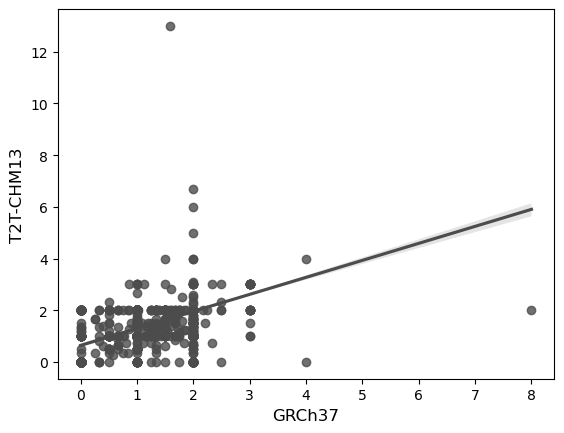

SignificanceResult(statistic=0.7213243674714258, pvalue=0.0)


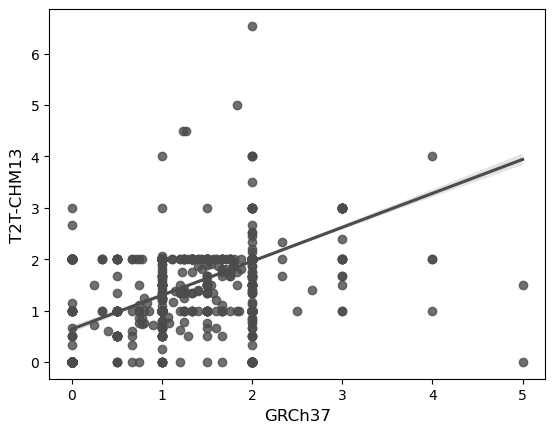

SignificanceResult(statistic=0.6804954630548744, pvalue=0.0)


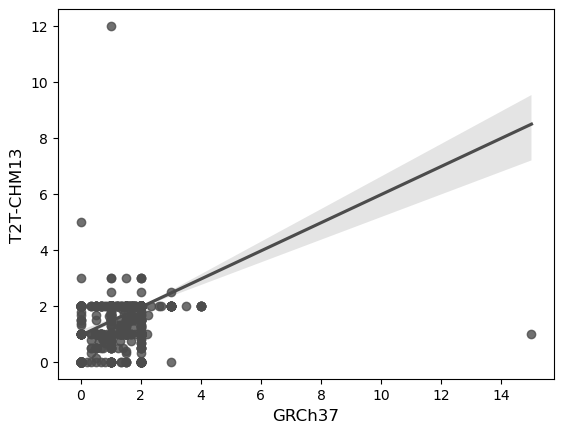

SignificanceResult(statistic=0.7265876938158842, pvalue=0.0)


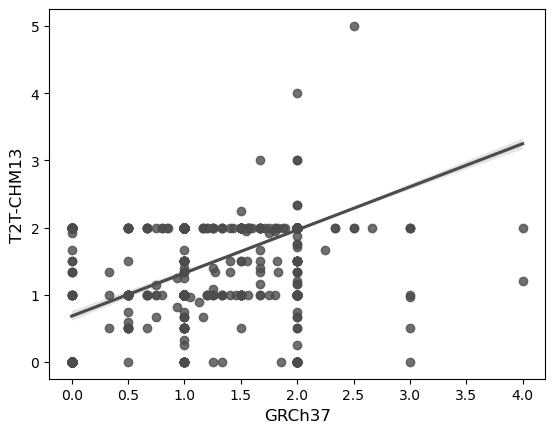

SignificanceResult(statistic=0.6873408365423535, pvalue=0.0)


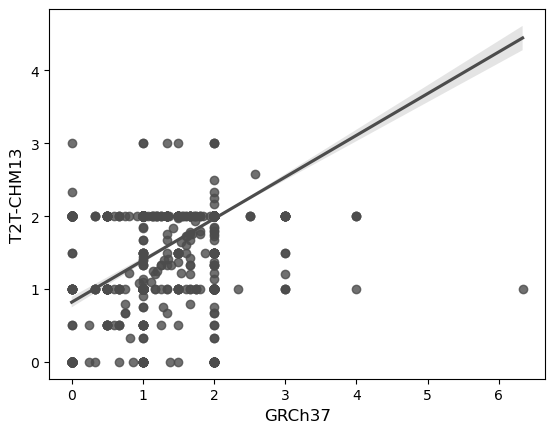

SignificanceResult(statistic=0.69778134531433, pvalue=0.0)


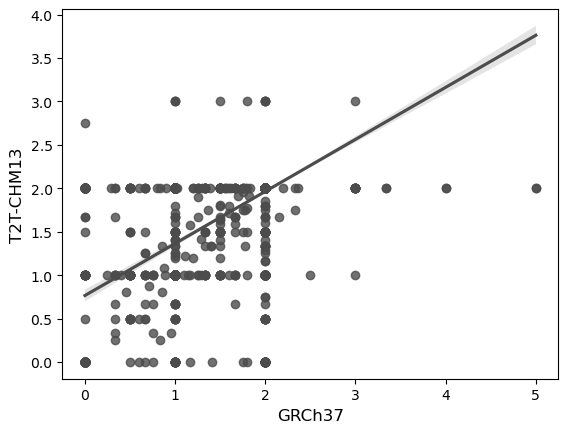

SignificanceResult(statistic=0.6680734447370176, pvalue=0.0)


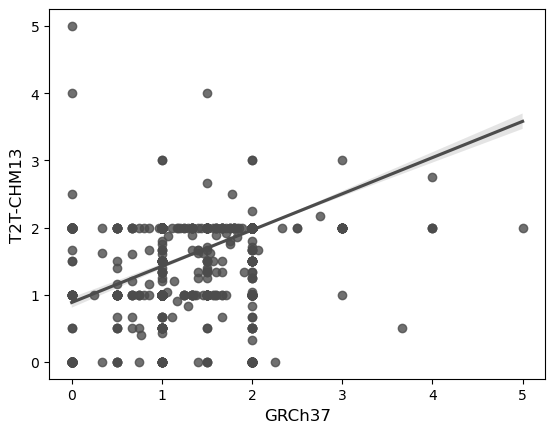

SignificanceResult(statistic=0.7062338953696524, pvalue=0.0)


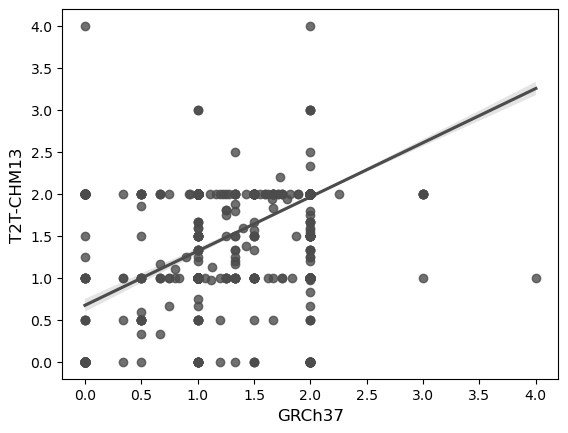

SignificanceResult(statistic=0.7098095722037793, pvalue=0.0)


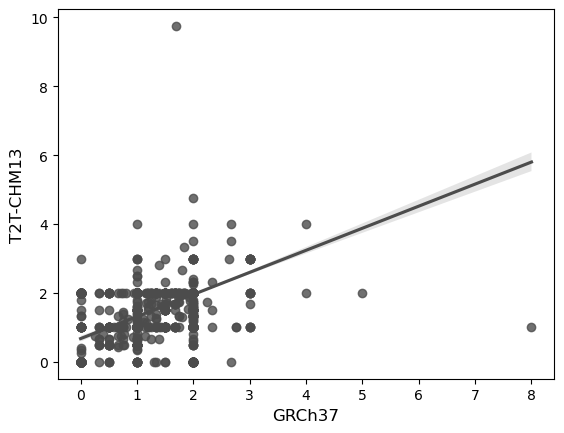

SignificanceResult(statistic=0.7220400016604209, pvalue=0.0)


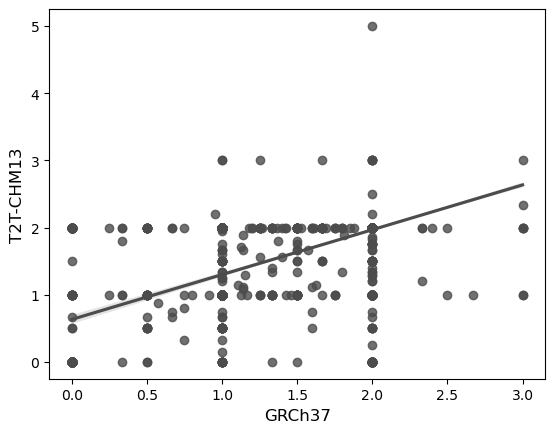

SignificanceResult(statistic=0.6822553380104848, pvalue=0.0)


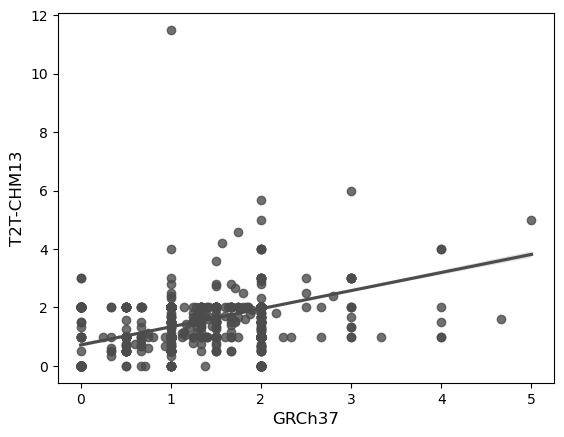

SignificanceResult(statistic=0.6785613270362069, pvalue=0.0)


KeyboardInterrupt: 

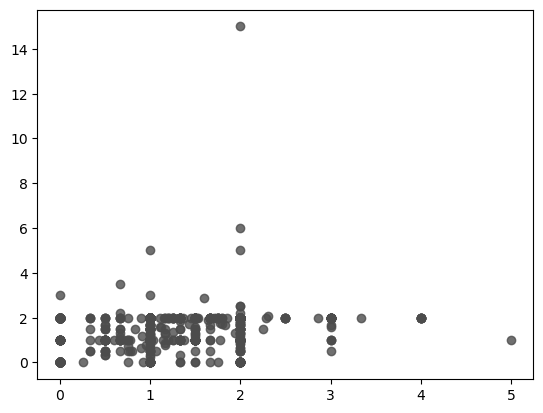

In [132]:
for i in data_chm13_.columns:
    st = stats.spearmanr(grch38_to_t2t_cnvs[i+str('_x')], grch38_to_t2t_cnvs[i+str('_y')])
    print(st)
    ax =  sns.regplot(data=grch38_to_t2t_cnvs, x=i+str('_x'), y=i+str('_y'), color=".3")
    ax.set_xlabel('GRCh37', size = 12)
    ax.set_ylabel('T2T-CHM13', size = 12)
#plt.savefig('../plots/Figure5a.png', transparent=True)
    plt.show()
    




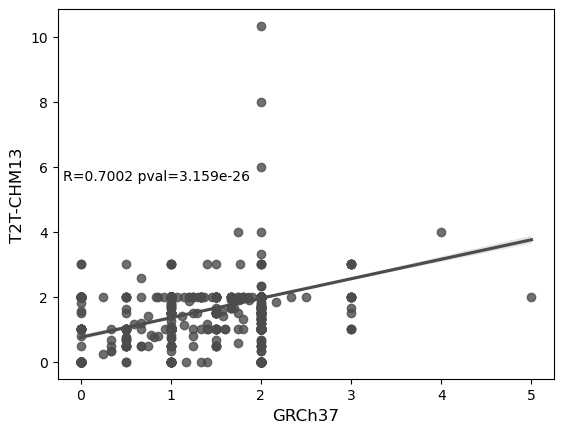

In [133]:
ax =  sns.regplot(data=grch38_to_t2t_cnvs, x="HG00097_x", y="HG00097_y", color=".3")
ax.set_xlabel('GRCh37', size = 12)
ax.set_ylabel('T2T-CHM13', size = 12)


plt.text(-0.2,5.6,('R=0.7002 pval=3.159e-26'), fontsize=10)
#plt.savefig('../plots/Figure5a.png', transparent=True)
plt.show()

<h3> Differences on liftover 

In [134]:
# GRCh38 to T2T-CHM13

# All CNVs
cnvs_counts_grch38_to_t2t = len(input_scatter_all_vst)
cnvs_counts_grch38 = len(data_grch37)
cnvs_counts_t2t = len(data_chm13)

#Differentiated CNVs 
cnvs_counts_grch38_to_t2t_differentiated = len(vst_grch37_ranges)
cnvs_counts_vst_t2t = len(vst_chm13)
cnvs_counts_vst_grch38 = len(vst_grch37)

<h2> Figure 6 

/opt/anaconda3/lib/python3.12/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


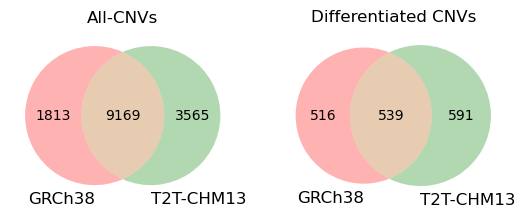

In [135]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib_venn import venn2_unweighted


plt.subplot(1, 2, 1) # row 1, col 2 index 1
venn2_unweighted(subsets = ((cnvs_counts_grch38-cnvs_counts_grch38_to_t2t),(cnvs_counts_t2t-cnvs_counts_grch38_to_t2t),cnvs_counts_grch38_to_t2t), set_labels = ('GRCh38', 'T2T-CHM13'), alpha = 0.3)
plt.title("All-CNVs")
plt.xlabel('X-axis ')
plt.ylabel('Y-axis ')

plt.subplot(1, 2, 2) # index 2
venn2(subsets = ((cnvs_counts_vst_grch38-cnvs_counts_grch38_to_t2t_differentiated),(cnvs_counts_vst_t2t-cnvs_counts_grch38_to_t2t_differentiated),cnvs_counts_grch38_to_t2t_differentiated), set_labels = ('GRCh38', 'T2T-CHM13'), alpha = 0.3)
plt.title("Differentiated CNVs")
plt.xlabel('X-axis ')
plt.ylabel('Y-axis ')

plt.savefig('../plots/venn_diagram_shared_cnvs_among_assemblies_hprc.png', transparent=True)

In [136]:
## Redoing all but now T2T liftover to GRCh38 

In [137]:
header_1 = ['Chromosome','Start', 'End', 'Original','Strain']
header_2 = ['Chromosome', 'Start' , 'End']
header_3 = ['Chromosome', 'Start' , 'End', 'Type']
header_4 = ['Chromosome','Start', 'End', 'Type','Strain']

grch37_to_t2t = pd.read_csv('/Users/luciabazan/Downloads/t2t_vst_candidates_to_grch38_coordinates.bed', sep='\t', names=header_1)
grch37_to_t2t_all = pd.read_csv('/Users/luciabazan/Downloads/t2t_cnvs_to_grch38_coordinates.bed.bed', sep='\t', names=header_1)
grch37_to_t2t_all = PyRanges(grch37_to_t2t_all)


#### GRCh37 vst to T2T vst 
grch37_to_t2t = PyRanges(grch37_to_t2t)

In [138]:
vst_grch37

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
3,chr1,713327,714478,0.15396,0.21193,0.29407,0.18103,0.00526,0.08644,0.00468,0.06728,0.00001,0.05148
5,chr1,729842,914823,0.33836,0.14385,0.38596,0.37557,0.05861,0.00106,0.00011,0.05193,0.06000,0.00060
11,chr1,1444487,1534886,0.22184,0.16136,0.33825,0.17075,0.01518,0.02553,0.00614,0.08516,0.00180,0.06136
21,chr1,2976522,2977705,0.17556,0.10969,0.09944,0.20829,0.02427,0.01501,0.00571,0.00059,0.05195,0.03731
22,chr1,3299144,3300425,0.29022,0.25884,0.08182,0.06764,0.00877,0.12221,0.15379,0.08257,0.11185,0.00248
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10967,chr9,137359057,137361507,0.08183,0.19943,0.00460,0.20035,0.03155,0.04676,0.03286,0.14329,0.00002,0.16162
10972,chr9,137818517,137819670,0.41559,0.32217,0.29870,0.29925,0.06092,0.03172,0.02036,0.00323,0.00609,0.00059
10976,chr9,138017889,138019594,0.30675,0.00058,0.24628,0.14216,0.31808,0.00107,0.05687,0.25977,0.14251,0.03732
10978,chr9,138125044,138139226,0.00104,0.21592,0.03617,0.08680,0.17672,0.02422,0.06585,0.08710,0.03852,0.01325


In [139]:
vst_t2t_ranges = PyRanges(vst_grch37)
grch37_to_t2tchm13 = grch37_to_t2t.nearest(vst_t2t_ranges)
grch37_to_t2tchm13 = grch37_to_t2tchm13.as_df()

grch37_to_t2tchm13 = grch37_to_t2tchm13[grch37_to_t2tchm13['Distance'] < 2000]

## Getting original coordinates
grch37_to_t2tchm13[['Chromosome_old','coordinates_old']] = grch37_to_t2tchm13.Original.str.split(":", expand = True)
grch37_to_t2tchm13[['Start_old','End_old']] = grch37_to_t2tchm13.coordinates_old.str.split("-", expand = True)
grch37_to_t2tchm13['End_old'] = grch37_to_t2tchm13['End_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'] -1 

vst_grch37_ranges = grch37_to_t2tchm13.merge(vst_t2t, left_on=['Start_old','Chromosome'], right_on=['Start','Chromosome'])
vst_grch37_ranges = vst_grch37_ranges.drop_duplicates(subset=['Start_b', 'End_b'])
vst_grch37_ranges

,Chromosome,Start_x,End_x,Original,Strain,Start_b,End_b,AFR-AMR_x,AFR-EAS_x,AFR-EUR_x,...,AFR-AMR_y,AFR-EAS_y,AFR-EUR_y,AFR-SAS_y,AMR-EAS_y,AMR-EUR_y,AMR-SAS_y,EAS-EUR_y,EAS-SAS_y,EUR-SAS_y
0,chr1,729842,914823,chr1:156353-344468,1,729842,914823,0.33836,0.14385,0.38596,...,0.21819,0.07125,0.13836,0.16495,0.03700,0.00489,0.00760,0.01257,0.01339,0.00007
2,chr1,1444487,1534886,chr1:878860-969390,1,1444487,1534886,0.22184,0.16136,0.33825,...,0.22657,0.16643,0.34143,0.16634,0.01518,0.02553,0.00812,0.08516,0.00088,0.06765
4,chr1,3299144,3300425,chr1:2803393-2804673,1,3299144,3300425,0.29022,0.25884,0.08182,...,0.29587,0.25390,0.07660,0.05706,0.01055,0.13540,0.17160,0.08548,0.11891,0.00375
5,chr1,7510013,7511457,chr1:7039443-7040886,1,7510013,7511457,0.03464,0.24902,0.07014,...,0.03551,0.25116,0.07121,0.07604,0.13025,0.00934,0.01072,0.06776,0.06988,0.00003
6,chr1,8951975,8957443,chr1:8485661-8491128,1,8951975,8957443,0.00906,0.04427,0.34994,...,0.07711,0.05404,0.25577,0.03885,0.00591,0.05387,0.00812,0.10940,0.00042,0.11221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,chr22,44739366,44741639,chr22:45223095-45225383,1,44739366,44741639,0.02054,0.06216,0.24072,...,0.02087,0.06172,0.23140,0.25339,0.01056,0.16975,0.18481,0.12466,0.13717,0.00000
567,chr22,45158837,45161242,chr22:45643327-45645731,1,45158837,45161242,0.22101,0.05391,0.20334,...,0.22531,0.05654,0.20696,0.08111,0.09191,0.00969,0.09727,0.09453,0.00343,0.11494
568,chr22,45257851,45260907,chr22:45742945-45745996,1,45257851,45260929,0.22157,0.15904,0.22139,...,0.23685,0.17308,0.23545,0.21253,0.02486,0.01965,0.00042,0.05753,0.01852,0.02604
569,chr22,47383373,47386791,chr22:47874804-47878221,1,47383373,47386791,0.00046,0.48798,0.02229,...,0.00178,0.50247,0.02810,0.15418,0.49524,0.02058,0.14368,0.34291,0.17947,0.05243


In [140]:
vst_dt_t2t_ranges

,Chromosome,Start,End,AFR-AMR,AFR-EAS,AFR-EUR,AFR-SAS,AMR-EAS,AMR-EUR,AMR-SAS,EAS-EUR,EAS-SAS,EUR-SAS
0,chr1,736,3272,0.00000,0.00016,0.00440,0.00174,0.00012,0.00477,0.00166,0.00662,0.00094,0.01282
1,chr1,24123,26129,0.01255,0.01052,0.01899,0.00715,0.00013,0.00111,0.00089,0.00193,0.00033,0.00422
2,chr1,34674,134000,0.13725,0.05104,0.13666,0.11749,0.02525,0.00005,0.00032,0.02512,0.01870,0.00016
3,chr1,139890,140991,0.00650,0.00709,0.00518,0.00583,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
4,chr1,151553,153659,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12729,chr22,51136085,51158037,0.03755,0.00651,0.04830,0.00792,0.01247,0.00093,0.00913,0.01956,0.00014,0.01578
12730,chr22,51193635,51195108,0.00820,0.01144,0.01203,0.00491,0.00026,0.00107,0.00042,0.00029,0.00133,0.00282
12731,chr22,51196249,51198088,0.06307,0.02845,0.06461,0.03258,0.01059,0.00108,0.00719,0.01617,0.00047,0.01335
12732,chr22,51313529,51314814,0.00210,0.00000,0.05238,0.14771,0.00214,0.04141,0.18366,0.05106,0.13880,0.31256


In [141]:
## ALL CNVS 

## ALL CNVS 

### GRCh37 all CNVs to T2T all CNVs 
vst_dt_t2t_ranges = PyRanges(vst_dt_grch37)
grch37_to_t2tchm13 = grch37_to_t2t_all.nearest(vst_dt_t2t_ranges)
grch37_to_t2tchm13 = grch37_to_t2tchm13.as_df()
grch37_to_t2tchm13  =grch37_to_t2tchm13[grch37_to_t2tchm13['Distance'] < 2]

## Getting vst values 
grch37_to_t2tchm13[['Chromosome_old','coordinates_old']] = grch37_to_t2tchm13.Original.str.split(":", expand = True)
grch37_to_t2tchm13[['Start_old','End_old']] = grch37_to_t2tchm13.coordinates_old.str.split("-", expand = True)

grch37_to_t2tchm13['End_old'] = grch37_to_t2tchm13['End_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'].astype('int64')
grch37_to_t2tchm13['Start_old'] = grch37_to_t2tchm13['Start_old'] -1 
grch37_to_t2tchm13

input_scatter_all_vst = grch37_to_t2tchm13.merge(vst_dt_chm13, left_on=['Start_old','Chromosome'], right_on=['Start','Chromosome'])
input_scatter_all_vst = input_scatter_all_vst.drop_duplicates(subset=['Start_b', 'End_b'])

input_scatter_all_vst

,Chromosome,Start_x,End_x,Original,Strain,Start_b,End_b,AFR-AMR_x,AFR-EAS_x,AFR-EUR_x,...,AFR-AMR_y,AFR-EAS_y,AFR-EUR_y,AFR-SAS_y,AMR-EAS_y,AMR-EUR_y,AMR-SAS_y,EAS-EUR_y,EAS-SAS_y,EUR-SAS_y
0,chr1,368747,369907,chr1:24124-26129,1,126241,707779,0.00236,0.00010,0.00045,...,0.01255,0.01052,0.01899,0.00715,0.00013,0.00111,0.00089,0.00193,0.00033,0.00422
2,chr1,713327,714478,chr1:139891-140991,1,713327,714478,0.15396,0.21193,0.29407,...,0.00650,0.00709,0.00518,0.00583,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
3,chr1,725043,727149,chr1:151554-153659,1,725043,728380,0.07495,0.12673,0.09585,...,0.15864,0.21971,0.17032,0.18792,0.02556,0.01965,0.02175,0.00000,0.00000,0.00000
4,chr1,729842,914823,chr1:156353-344468,1,729842,914823,0.33836,0.14385,0.38596,...,0.21819,0.07125,0.13836,0.16495,0.03700,0.00489,0.00760,0.01257,0.01339,0.00007
6,chr1,976708,977994,chr1:405418-407835,1,976708,978019,0.01587,0.03859,0.03299,...,0.11104,0.14098,0.02657,0.06649,0.00427,0.02555,0.00871,0.04221,0.02272,0.00661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10798,chr22,50343869,50345691,chr22:50851734-50853524,1,50343869,50345691,0.10695,0.00098,0.00202,...,0.09842,0.09000,0.10786,0.07225,0.00065,0.00367,0.00156,0.00687,0.00022,0.00895
10799,chr22,50433190,50434839,chr22:50942386-50944034,1,50433228,50434839,0.16628,0.08639,0.18063,...,0.10303,0.09539,0.19071,0.16041,0.00029,0.04479,0.01791,0.04511,0.02050,0.00634
10800,chr22,50490491,50494732,chr22:50999674-51003908,1,50490491,50494732,0.00000,0.01117,0.00000,...,0.00000,0.01125,0.00000,0.00000,0.00935,0.00000,0.00000,0.00759,0.00847,0.00000
10801,chr22,50625574,50644081,chr22:51136086-51158037,1,50629205,50640118,0.00000,0.00370,0.01129,...,0.03755,0.00651,0.04830,0.00792,0.01247,0.00093,0.00913,0.01956,0.00014,0.01578


/opt/anaconda3/lib/python3.12/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


Text(0, 0.5, 'Y-axis ')

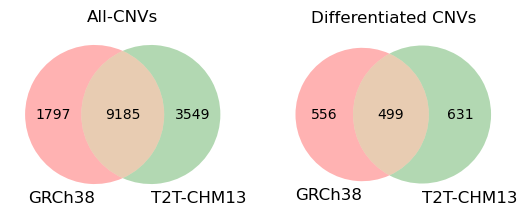

In [142]:
# GRCh38 to T2T-CHM13

# All CNVs
cnvs_counts_grch38_to_t2t = len(input_scatter_all_vst)
cnvs_counts_grch38 = len(data_grch37)
cnvs_counts_t2t = len(data_chm13)

#Differentiated CNVs 
cnvs_counts_grch38_to_t2t_differentiated = len(vst_grch37_ranges)
cnvs_counts_vst_t2t = len(vst_chm13)
cnvs_counts_vst_grch38 = len(vst_grch37)


plt.subplot(1, 2, 1) # row 1, col 2 index 1
venn2_unweighted(subsets = ((cnvs_counts_grch38-cnvs_counts_grch38_to_t2t),(cnvs_counts_t2t-cnvs_counts_grch38_to_t2t),cnvs_counts_grch38_to_t2t), set_labels = ('GRCh38', 'T2T-CHM13'), alpha = 0.3)
plt.title("All-CNVs")
plt.xlabel('X-axis ')
plt.ylabel('Y-axis ')

plt.subplot(1, 2, 2) # index 2
venn2(subsets = ((cnvs_counts_vst_grch38-cnvs_counts_grch38_to_t2t_differentiated),(cnvs_counts_vst_t2t-cnvs_counts_grch38_to_t2t_differentiated),cnvs_counts_grch38_to_t2t_differentiated), set_labels = ('GRCh38', 'T2T-CHM13'), alpha = 0.3)
plt.title("Differentiated CNVs")
plt.xlabel('X-axis ')
plt.ylabel('Y-axis ')

#plt.savefig('../plots/venn_diagram_shared_cnvs_among_assemblies_hprc.png', transparent=True)